# Imports

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import awkward           as ak
import numpy             as np
import pandas            as pd

from nHits_trigger.src.read_data          import nHits, read_mpmt_offsets
from WCTE_BRB_Data_Analysis.wcte.brbtools import sort_run_files, get_part_files
from matplotlib.backends.backend_pdf      import PdfPages

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Read Data And Correct TOF

In [2]:
bkg_run = 1766

bkg_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{bkg_run}/WCTE_offline_R{bkg_run}S*P*.root")
bkg_part_files = get_part_files(bkg_run_files)

# Run Variables
bkg_run_corrected_times           = []
bkg_run_hit_charges               = []
bkg_run_hit_card_ids              = []
bkg_run_hit_channel_ids           = []
bkg_run_hit_slot_ids              = []
bkg_run_hit_position_ids          = []
bkg_run_hit_pmt_has_time_constant = []

ev_offset = 0
for part in bkg_part_files[:3]:
    print(f"Processing part WCTE_offline_R{bkg_run}S0P{part}")
    bkg_tree = uproot.open(bkg_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    bkg_file_hit_card_ids              = ak.values_astype(bkg_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    bkg_file_hit_channel_ids           = ak.values_astype(bkg_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    bkg_file_hit_times                 = ak.values_astype(bkg_tree["hit_pmt_times"]            .array(), np.float64)
    bkg_file_hit_times_calib           = ak.values_astype(bkg_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    bkg_file_hit_charges               = ak.values_astype(bkg_tree["hit_pmt_charges"]          .array(), np.float64)
    bkg_file_hit_slot_ids              = ak.values_astype(bkg_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    bkg_file_hit_position_ids          = ak.values_astype(bkg_tree["hit_pmt_position_ids"]     .array(), np.int16)
    bkg_file_hit_pmt_has_time_constant = ak.values_astype(bkg_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    bkg_flat_slot_ids     = ak.ravel(bkg_file_hit_slot_ids)
    bkg_flat_pos_ids      = ak.ravel(bkg_file_hit_position_ids)
    bkg_flat_corrections  = lookup[bkg_flat_slot_ids, bkg_flat_pos_ids]
    bkg_corrections       = ak.unflatten(bkg_flat_corrections, ak.num(bkg_file_hit_card_ids))

    bkg_term1           = bkg_file_hit_times_calib
    bkg_corrected_times = bkg_term1 #- bkg_corrections 

    # Filter Out Main Things
    mask = (bkg_file_hit_charges < 1e4) & (bkg_file_hit_card_ids < 120) & (bkg_file_hit_pmt_has_time_constant != 0)
    bkg_corrected_times                = bkg_corrected_times                [mask]
    bkg_file_hit_charges               = bkg_file_hit_charges               [mask]
    bkg_file_hit_card_ids              = bkg_file_hit_card_ids              [mask]
    bkg_file_hit_channel_ids           = bkg_file_hit_channel_ids           [mask]
    bkg_file_hit_slot_ids              = bkg_file_hit_slot_ids              [mask]
    bkg_file_hit_position_ids          = bkg_file_hit_position_ids          [mask]
    bkg_file_hit_pmt_has_time_constant = bkg_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(bkg_corrected_times)
    
    bkg_run_corrected_times          .append(bkg_corrected_times               [order])
    bkg_run_hit_charges              .append(bkg_file_hit_charges              [order])
    bkg_run_hit_card_ids             .append(bkg_file_hit_card_ids             [order])    
    bkg_run_hit_channel_ids          .append(bkg_file_hit_channel_ids          [order]) 
    bkg_run_hit_slot_ids             .append(bkg_file_hit_slot_ids             [order])    
    bkg_run_hit_position_ids         .append(bkg_file_hit_position_ids         [order])
    bkg_run_hit_pmt_has_time_constant.append(bkg_file_hit_pmt_has_time_constant[order])

bkg_run_corrected_times           = ak.concatenate(bkg_run_corrected_times          )
bkg_run_hit_charges               = ak.concatenate(bkg_run_hit_charges              )
bkg_run_hit_card_ids              = ak.concatenate(bkg_run_hit_card_ids             )
bkg_run_hit_channel_ids           = ak.concatenate(bkg_run_hit_channel_ids          )
bkg_run_hit_slot_ids              = ak.concatenate(bkg_run_hit_slot_ids             )
bkg_run_hit_position_ids          = ak.concatenate(bkg_run_hit_position_ids         )
bkg_run_hit_pmt_has_time_constant = ak.concatenate(bkg_run_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1766S0P0
Processing part WCTE_offline_R1766S0P1
Processing part WCTE_offline_R1766S0P2


In [3]:
nicf_run = 1771

nicf_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{nicf_run}/WCTE_offline_R{nicf_run}S*P*.root")
nicf_part_files = get_part_files(nicf_run_files)

# Run Variables
nicf_run_tof_corrected_times           = []
nicf_run_tof_hit_charges               = []
nicf_run_tof_hit_card_ids              = []
nicf_run_tof_hit_channel_ids           = []
nicf_run_tof_hit_slot_ids              = []
nicf_run_tof_hit_position_ids          = []
nicf_run_tof_hit_pmt_has_time_constant = []

ev_offset = 0
for part in nicf_part_files[:3]:
    print(f"Processing part WCTE_offline_R{nicf_run}S0P{part}")
    nicf_tree = uproot.open(nicf_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    nicf_file_hit_card_ids              = ak.values_astype(nicf_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    nicf_file_hit_channel_ids           = ak.values_astype(nicf_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    nicf_file_hit_times                 = ak.values_astype(nicf_tree["hit_pmt_times"]            .array(), np.float64)
    nicf_file_hit_times_calib           = ak.values_astype(nicf_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    nicf_file_hit_charges               = ak.values_astype(nicf_tree["hit_pmt_charges"]          .array(), np.float64)
    nicf_file_hit_slot_ids              = ak.values_astype(nicf_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    nicf_file_hit_position_ids          = ak.values_astype(nicf_tree["hit_pmt_position_ids"]     .array(), np.int16)
    nicf_file_hit_pmt_has_time_constant = ak.values_astype(nicf_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    nicf_flat_slot_ids     = ak.ravel(nicf_file_hit_slot_ids)
    nicf_flat_pos_ids      = ak.ravel(nicf_file_hit_position_ids)
    nicf_flat_corrections  = lookup[nicf_flat_slot_ids, nicf_flat_pos_ids]
    nicf_corrections       = ak.unflatten(nicf_flat_corrections, ak.num(nicf_file_hit_card_ids))

    nicf_term1           = nicf_file_hit_times_calib
    nicf_corrected_times = nicf_term1 - nicf_corrections 

    # Filter Out Main Things
    mask = (nicf_file_hit_charges < 1e4) & (nicf_file_hit_card_ids < 120) & (nicf_file_hit_pmt_has_time_constant != 0)
    nicf_corrected_times                = nicf_corrected_times                [mask]
    nicf_file_hit_charges               = nicf_file_hit_charges               [mask]
    nicf_file_hit_card_ids              = nicf_file_hit_card_ids              [mask]
    nicf_file_hit_channel_ids           = nicf_file_hit_channel_ids           [mask]
    nicf_file_hit_slot_ids              = nicf_file_hit_slot_ids              [mask]
    nicf_file_hit_position_ids          = nicf_file_hit_position_ids          [mask]
    nicf_file_hit_pmt_has_time_constant = nicf_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(nicf_corrected_times)
    
    nicf_run_tof_corrected_times          .append(nicf_corrected_times               [order])
    nicf_run_tof_hit_charges              .append(nicf_file_hit_charges              [order])
    nicf_run_tof_hit_card_ids             .append(nicf_file_hit_card_ids             [order])    
    nicf_run_tof_hit_channel_ids          .append(nicf_file_hit_channel_ids          [order]) 
    nicf_run_tof_hit_slot_ids             .append(nicf_file_hit_slot_ids             [order])    
    nicf_run_tof_hit_position_ids         .append(nicf_file_hit_position_ids         [order])
    nicf_run_tof_hit_pmt_has_time_constant.append(nicf_file_hit_pmt_has_time_constant[order])

nicf_run_tof_corrected_times           = ak.concatenate(nicf_run_tof_corrected_times          )
nicf_run_tof_hit_charges               = ak.concatenate(nicf_run_tof_hit_charges              )
nicf_run_tof_hit_card_ids              = ak.concatenate(nicf_run_tof_hit_card_ids             )
nicf_run_tof_hit_channel_ids           = ak.concatenate(nicf_run_tof_hit_channel_ids          )
nicf_run_tof_hit_slot_ids              = ak.concatenate(nicf_run_tof_hit_slot_ids             )
nicf_run_tof_hit_position_ids          = ak.concatenate(nicf_run_tof_hit_position_ids         )
nicf_run_tof_hit_pmt_has_time_constant = ak.concatenate(nicf_run_tof_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1771S0P0


Processing part WCTE_offline_R1771S0P1
Processing part WCTE_offline_R1771S0P2


# Spills

In [4]:
len(bkg_run_corrected_times) == len(nicf_run_tof_corrected_times)

False

In [5]:
nicf_triggered_spill_hits_index_tof, nicf_triggered_spill_hit_times_tof = nHits(mode="multiple_events", hit_times=nicf_run_tof_corrected_times, w=5000, thresh_min=300, thresh_max=100000, pre_window=0, post_window=4000, jump=9000)
bkg_triggered_spill_hits_index, bkg_triggered_spill_hit_times           = nHits(mode="multiple_events", hit_times=bkg_run_corrected_times,      w=5000, thresh_min=300, thresh_max=100000, pre_window=0, post_window=4000, jump=9000)

  0%|          | 0/36609 [00:00<?, ?it/s]

100%|██████████| 47109/47109 [00:17<00:00, 2742.70it/s]


### Remove Spills from data

In [6]:
def remove_spill(trigger_indices, run_times):
    corrected_run_times = []

    for i in tqdm(range(len(run_times))):
        if i in trigger_indices:
            #Event with spill → remove selected indices
            if len(trigger_indices[i]) > 0:
                data = run_times[i]
                trigger_indices_event = np.concatenate(trigger_indices[i])
                all_indices           = np.arange(len(data))
                valid_indices         = np.setdiff1d(all_indices, trigger_indices_event)
                corrected_run_times.append(data[valid_indices])
            
            else:
                continue
        else:
            # Event without spill → leave as it is
            corrected_run_times.append(run_times[i])

    return ak.Array(corrected_run_times)

In [7]:
# Hit Time
nicf_noSpill_times_tof = remove_spill(nicf_triggered_spill_hits_index_tof, nicf_run_tof_corrected_times)
bkg_noSpill_times      = remove_spill(bkg_triggered_spill_hits_index, bkg_run_corrected_times)

100%|██████████| 47109/47109 [00:10<00:00, 4453.82it/s]


### Spill Analysis

In [8]:
#¿Cuántos spill estoy quitando por readout-window?

nOfSpillsPerEvent_sig = []
for k,v in nicf_triggered_spill_hit_times_tof.items():
    nOfSpillsPerEvent_sig.append(len(v))

nOfSpillsPerEvent_bkg = []
for k,v in bkg_triggered_spill_hit_times.items():
    nOfSpillsPerEvent_bkg.append(len(v))

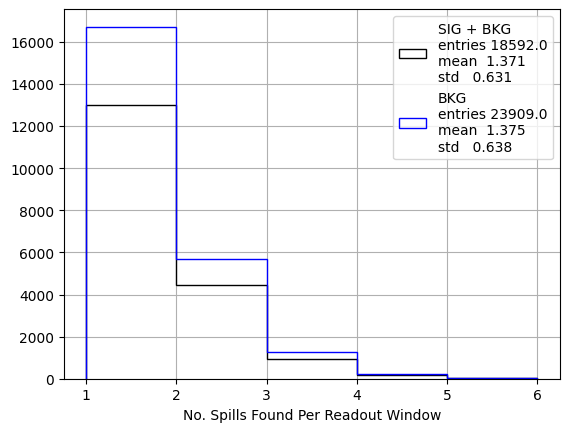

In [9]:
pltext.hist(nOfSpillsPerEvent_sig, 5, range=(1,6), xylabels="No. Spills Found Per Readout Window", label="SIG + BKG");
pltext.hist(nOfSpillsPerEvent_bkg, 5, range=(1,6), xylabels="No. Spills Found Per Readout Window", label="BKG");

In [10]:
# Distribución del número de hits en el spill (en 5000 ns y en los 4000 ns posteriores)

spill_size_sig = []

for k,v in tqdm(nicf_triggered_spill_hit_times_tof.items(), total=len(nicf_triggered_spill_hit_times_tof.items()), leave=False):
    for i in nicf_triggered_spill_hit_times_tof.get(k):
        spill_size_sig.append(len(i))

spill_size_bkg = []

for k,v in tqdm(bkg_triggered_spill_hit_times.items(), total=len(bkg_triggered_spill_hit_times.items()), leave=False):
    for i in bkg_triggered_spill_hit_times.get(k):
        spill_size_bkg.append(len(i))

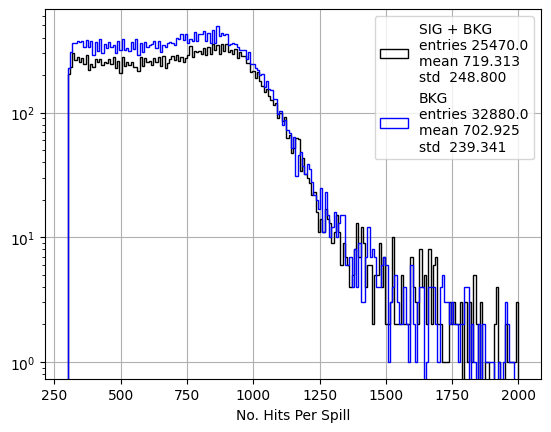

In [11]:
pltext.hist(spill_size_sig, 200, range=(300, 2000), ylog=True, xylabels="No. Hits Per Spill", label="SIG + BKG");
pltext.hist(spill_size_bkg, 200, range=(300, 2000), ylog=True, xylabels="No. Hits Per Spill", label="BKG");

# Candidates Analysis

In [12]:
def nHits(mode,
          hit_times,
          w,
          thresh_min,
          thresh_max,
          pre_window,
          post_window,
          jump,
          event=0,
          progress_bar=True):

    def process_event(ht,
                      w,
                      thresh_min,
                      thresh_max,
                      pre_window,
                      post_window,
                      jump):

        if len(ht) == 0:
            return [], [], [], []

        # Orden temporal
        ht = np.sort(ht)

        # ------------------------
        # Sliding window trigger
        # ------------------------

        ends = ht + w
        right = np.searchsorted(ht, ends, side="left")
        left = np.arange(len(ht))
        counts = right - left

        trigger_indices = np.where(counts >= thresh_min)[0]

        triggered_hits_index = []
        triggered_hits_time = []

        trigger_seeds = []      # t_seed (paper SLE crossing)
        roi_start_times = []   # primer hit físico del cluster

        last_cluster_end = -np.inf

        # ------------------------
        # Loop triggers
        # ------------------------

        for idx in trigger_indices:

            t_seed = ht[idx]

            # Deadtime basado en CLUSTER REAL
            if t_seed < last_cluster_end + jump:
                continue

            # ------------------------
            # ROI física
            # ------------------------

            t_min = t_seed - pre_window
            t_max = t_seed + w + post_window

            roi_mask = (ht >= t_min) & (ht <= t_max)
            indices_roi = np.where(roi_mask)[0]

            if len(indices_roi) < thresh_min:
                continue
            
            if thresh_max is not None and len(indices_roi) > thresh_max:
                continue

            hit_times_roi = ht[indices_roi]

            # ------------------------
            # Guardado
            # ------------------------

            triggered_hits_index.append(indices_roi)
            triggered_hits_time.append(hit_times_roi)

            trigger_seeds.append(t_seed)
            roi_start_times.append(hit_times_roi[0])

            # Deadtime real: fin del cluster físico
            last_cluster_end = hit_times_roi[-1]

        return triggered_hits_index, triggered_hits_time, trigger_seeds, roi_start_times

    # ==================================================
    # SINGLE EVENT
    # ==================================================

    if mode == "single_event":

        ht = ak.to_numpy(hit_times[event])

        idxs, times, seeds, roi_starts = process_event(
            ht,
            w,
            thresh_min,
            thresh_max,
            pre_window,
            post_window,
            jump
        )

        return ({event: idxs},
                {event: times},
                {event: seeds},
                {event: roi_starts})

    # ==================================================
    # MULTIPLE EVENTS
    # ==================================================

    elif mode == "multiple_events":

        nevents = len(hit_times)

        triggered_hits_index = {}
        triggered_hits_time = {}
        trigger_seeds_dict = {}
        roi_start_times_dict = {}

        for event in tqdm(range(nevents),
                          total=nevents,
                          leave=progress_bar):

            ht = ak.to_numpy(hit_times[event])

            if len(ht) == 0:
                triggered_hits_index[event] = []
                triggered_hits_time[event] = []
                trigger_seeds_dict[event] = []
                roi_start_times_dict[event] = []
                continue

            idxs, times, seeds, roi_starts = process_event(
                ht,
                w,
                thresh_min,
                thresh_max,
                pre_window,
                post_window,
                jump
            )

            triggered_hits_index[event] = idxs
            triggered_hits_time[event] = times
            trigger_seeds_dict[event] = seeds
            roi_start_times_dict[event] = roi_starts

        return (triggered_hits_index,
                triggered_hits_time,
                trigger_seeds_dict,
                roi_start_times_dict)

    else:
        print("enter a valid mode name")
        return {}, {}, {}, {}


In [13]:
thresh_inf          = 5   # hits
thresh_sup          = 60   # hits
sliding_window      = 20   # ns
pre_trigger_window  = 200
post_trigger_window = 200
dead_time           = pre_trigger_window + post_trigger_window    # ns

# nHits
nicf_triggered_signal_hits_index_tof, nicf_triggered_signal_hit_times_tof, nicf_d_seed_tof, nicf_d_roi_tof = nHits(mode="multiple_events", hit_times=nicf_noSpill_times_tof, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)
bkg_triggered_signal_hits_index_tof, bkg_triggered_signal_hit_times_tof, bkg_d_seed_tof, bkg_d_roi_tof     = nHits(mode="multiple_events", hit_times=bkg_noSpill_times,      w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)

# tRMS
nicf_rms_50ns_tof  = []
nicf_50ns_size_tof = []
for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items()), leave=False):
        for i in nicf_triggered_signal_hit_times_tof.get(k):
            nicf_rms_50ns_tof.append(np.std(i, ddof=0))
            nicf_50ns_size_tof.append(len(i))

bkg_rms_50ns  = []
bkg_50ns_size = []
for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items()), leave=False):
        for i in bkg_triggered_signal_hit_times_tof.get(k):
            bkg_rms_50ns.append(np.std(i, ddof=0))
            bkg_50ns_size.append(len(i))

100%|██████████| 47109/47109 [00:18<00:00, 2488.88it/s]


In [14]:
# Eliminamos ese candidato si en la ventana extendida [200, 20 + 200] hay alguna otra acumulación de hits > 10 en 20 ns 
# (que podemos llamar flash). Esto es en la ventana extendida solo está ese candidado con >10 hits 

doubleCandidates_sig = {}

for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items())):
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]
    for c in range(len(v)):
        
        candidate_to_investigate = [sett[c] - seed[c]]
        thresh_inf               = 10     # hits
        thresh_sup               = np.inf # hits
        sliding_window           = 20     # ns
        pre_trigger_window       = 0      # ns  
        post_trigger_window      = 0      # ns
        dead_time                = sliding_window + post_trigger_window

        test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)

        if len(test_triggered_signal_hit_times_tof[0]) > 1:
            # print(k, c, ":", len(test_triggered_signal_hit_times_tof[0]))
            doubleCandidates_sig[k] = c

doubleCandidates_bkg = {}

for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items())):
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]
    for c in range(len(v)):
        
        candidate_to_investigate = [sett[c] - seed[c]]
        thresh_inf               = 10     # hits
        thresh_sup               = np.inf # hits
        sliding_window           = 20     # ns
        pre_trigger_window       = 0      # ns  
        post_trigger_window      = 0      # ns
        dead_time                = sliding_window + post_trigger_window

        test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)

        if len(test_triggered_signal_hit_times_tof[0]) > 1:
            # print(k, c, ":", len(test_triggered_signal_hit_times_tof[0]))
            doubleCandidates_bkg[k] = c

100%|██████████| 47109/47109 [00:10<00:00, 4365.60it/s]


In [15]:
print(f"Estamos eliminando {len(doubleCandidates_sig)} candidatos por tener double triggers. Representa un {len(doubleCandidates_sig)/len(nicf_50ns_size_tof)*100:.2f}% del total de candidatos triggados.")
print(f"Estamos eliminando {len(doubleCandidates_bkg)} candidatos por tener double triggers. Representa un {len(doubleCandidates_bkg)/len(bkg_50ns_size)*100:.2f}% del total de candidatos triggados.")

Estamos eliminando 330 candidatos por tener double triggers. Representa un 0.08% del total de candidatos triggados.
Estamos eliminando 79 candidatos por tener double triggers. Representa un 0.07% del total de candidatos triggados.


In [16]:
from copy import deepcopy
from collections import defaultdict

nicf_triggered_signal_hit_times_tof_clean  = deepcopy(nicf_triggered_signal_hit_times_tof)
nicf_d_seed_tof_clean                      = deepcopy(nicf_d_seed_tof)
nicf_triggered_signal_hits_index_tof_clean = deepcopy(nicf_triggered_signal_hits_index_tof)

to_delete = defaultdict(list)
for k, idx in doubleCandidates_sig.items():
    to_delete[k].append(idx)

for k, indices in to_delete.items():
    for idx in sorted(indices, reverse=True):
        if k in nicf_triggered_signal_hit_times_tof_clean and idx < len(nicf_triggered_signal_hit_times_tof_clean[k]):
            del nicf_triggered_signal_hit_times_tof_clean[k][idx]
            del nicf_d_seed_tof_clean[k][idx]
            del nicf_triggered_signal_hits_index_tof_clean[k][idx]

bkg_triggered_signal_hit_times_tof_clean  = deepcopy(bkg_triggered_signal_hit_times_tof)
bkg_d_seed_tof_clean                      = deepcopy(bkg_d_seed_tof)
bkg_triggered_signal_hits_index_tof_clean = deepcopy(bkg_triggered_signal_hits_index_tof)

to_delete = defaultdict(list)
for k, idx in doubleCandidates_bkg.items():
    to_delete[k].append(idx)

for k, indices in to_delete.items():
    for idx in sorted(indices, reverse=True):
        if k in bkg_triggered_signal_hit_times_tof_clean and idx < len(bkg_triggered_signal_hit_times_tof_clean[k]):
            del bkg_triggered_signal_hit_times_tof_clean[k][idx]
            del bkg_d_seed_tof_clean[k][idx]
            del bkg_triggered_signal_hits_index_tof_clean[k][idx]

# 1st Purity Calculation

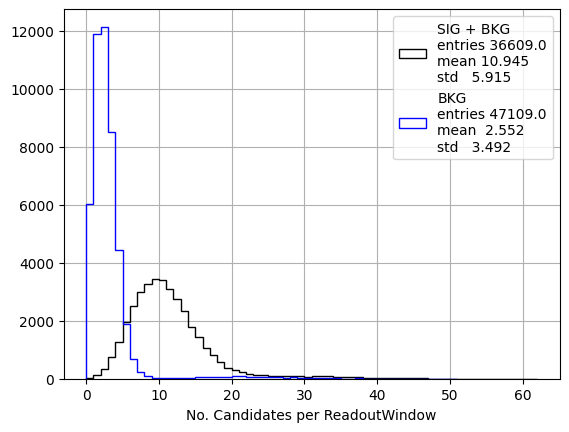

In [17]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    candidates_per_redaoutWindow_sig.append(len(v))

candidates_per_redaoutWindow_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof.items():
    candidates_per_redaoutWindow_bkg.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig, np.max(candidates_per_redaoutWindow_sig), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg, np.max(candidates_per_redaoutWindow_bkg), xylabels="No. Candidates per ReadoutWindow", label="BKG");

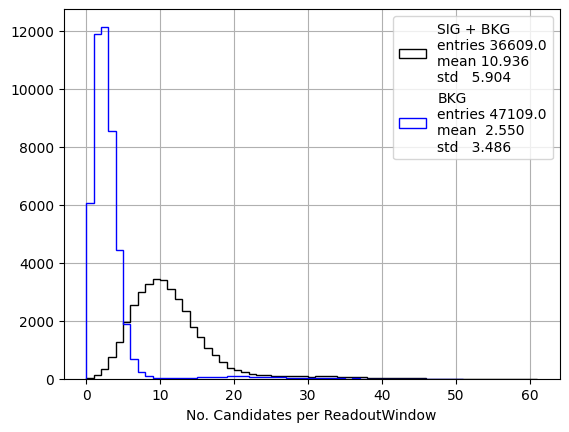

In [18]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig_clean = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    candidates_per_redaoutWindow_sig_clean.append(len(v))

candidates_per_redaoutWindow_bkg_clean = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    candidates_per_redaoutWindow_bkg_clean.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig_clean, np.max(candidates_per_redaoutWindow_sig_clean), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg_clean, np.max(candidates_per_redaoutWindow_bkg_clean), xylabels="No. Candidates per ReadoutWindow", label="BKG");

# $t_c$, $t_{RMS}$ and nHits In The Small Sliding Window

### Plots, Non PDFs

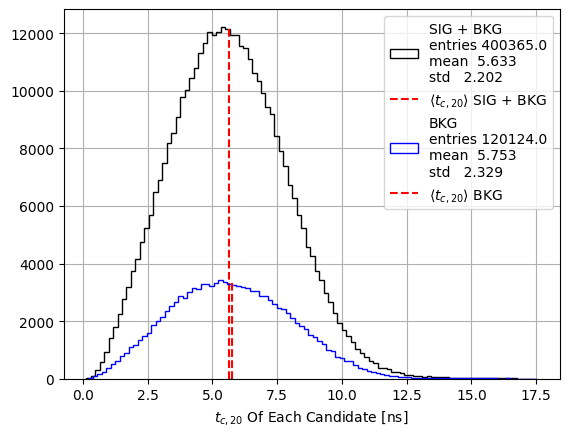

In [19]:
# 1. Calcular el tc de ese candidato como el promedio del tiempo de sus hits (los que están en la venta).

tc_20_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            tc_20_sig.append(mean_val)

tc_20_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett < shifted_seed+20)
        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            tc_20_bkg.append(mean_val)

h = pltext.hist(tc_20_sig, 100, ylog=False, xylabels="$t_{c, 20}$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(tc_20_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{c, 20} \rangle$ SIG + BKG");
h = pltext.hist(tc_20_bkg, 100, ylog=False, xylabels="$t_{c, 20}$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(tc_20_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{c, 20} \rangle$ BKG");
plt.legend();

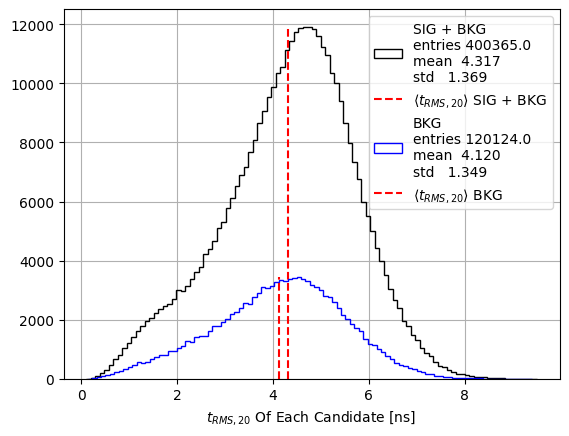

In [20]:
trms_20_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        std_val = np.std(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if std_val is not None:
            trms_20_sig.append(std_val)

trms_20_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett < shifted_seed+20)
        std_val = np.std(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if std_val is not None:
            trms_20_bkg.append(std_val)

h = pltext.hist(trms_20_sig, 100, ylog=False, xylabels="$t_{RMS, 20}$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(trms_20_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{RMS, 20} \rangle$ SIG + BKG");
h = pltext.hist(trms_20_bkg, 100, ylog=False, xylabels="$t_{RMS, 20}$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(trms_20_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{RMS, 20} \rangle$ BKG");
plt.legend();

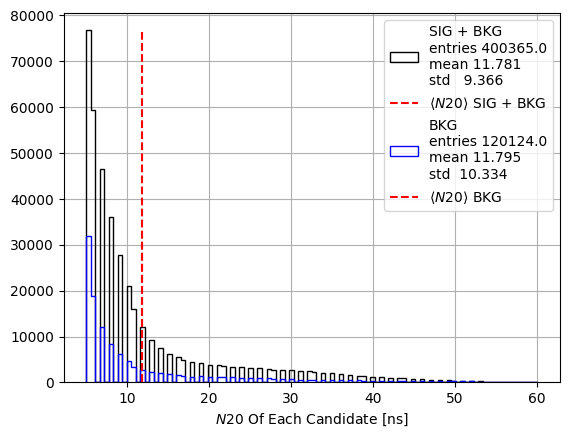

In [21]:
nhits_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        nhits_val = len(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if nhits_val is not None:
            nhits_sig.append(nhits_val)

nhits_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        nhits_val = len(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if nhits_val is not None:
            nhits_bkg.append(nhits_val)

h = pltext.hist(nhits_sig, 100, ylog=False, xylabels="$N20$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(nhits_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle N20 \rangle$ SIG + BKG");
h = pltext.hist(nhits_bkg, 100, ylog=False, xylabels="$N20$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(nhits_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle N20 \rangle$ BKG");
plt.legend();

### $t_c$, $t_{RMS}$ and nHits As PDFs

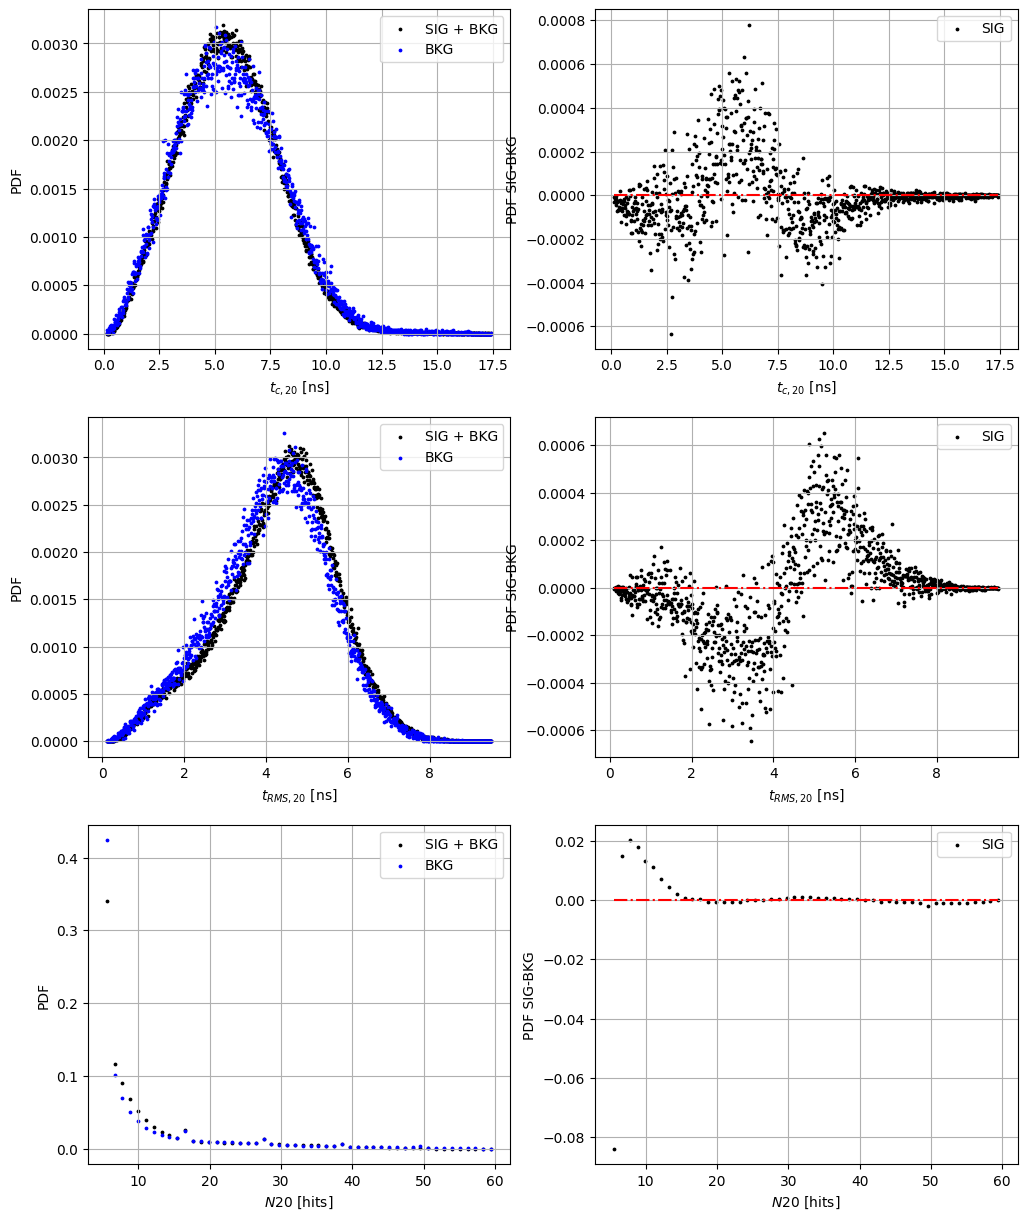

In [22]:
subplot = pltext.canvas(6)
###################################
# tc
###################################
hs = np.histogram(tc_20_sig, 1000);
hb = np.histogram(tc_20_bkg, 1000);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(1)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$t_{c, 20}$ [ns]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(2)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$t_{c, 20}$ [ns]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

###################################
# trms
###################################
hs = np.histogram(trms_20_sig, 1000);
hb = np.histogram(trms_20_bkg, 1000);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(3)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$t_{RMS, 20}$ [ns]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(4)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$t_{RMS, 20}$ [ns]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

###################################
# nhits
###################################
hs = np.histogram(nhits_sig, 50);
hb = np.histogram(nhits_bkg, 50);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(5)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$N20$ [hits]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(6)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$N20$ [hits]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

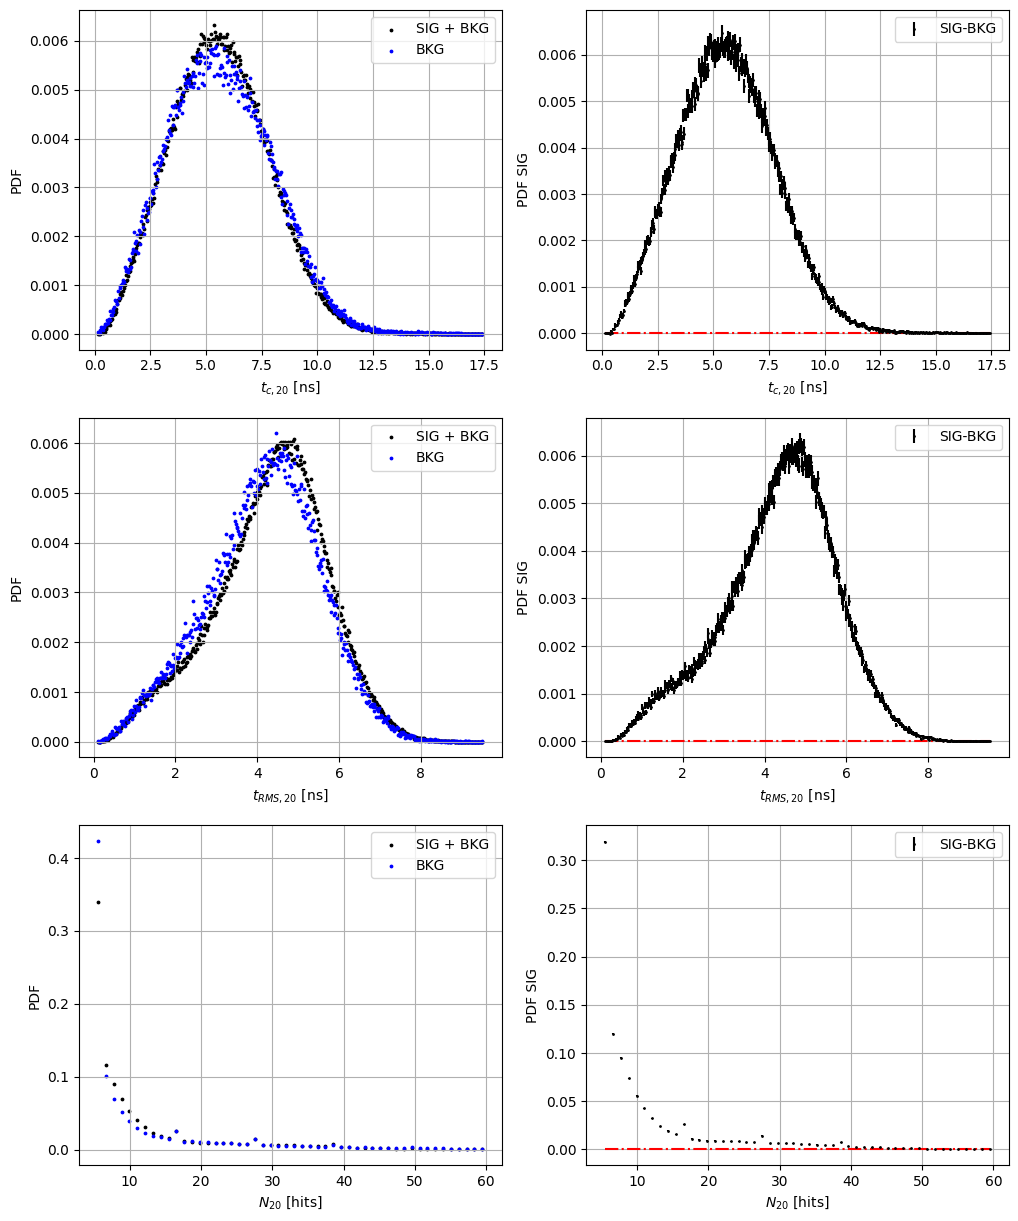

In [23]:
def plot_pdf_with_sub(sig_list, bkg_list, bins, xlabel, subplot_idx):
    subplot(subplot_idx)  # activa la subventana
    hs = np.histogram(sig_list, bins=bins)
    hb = np.histogram(bkg_list, bins=bins)
    
    bin_centers = (hs[1][:-1] + hs[1][1:]) / 2
    pdf_sig = hs[0] / np.sum(hs[0])
    pdf_bkg = hb[0] / np.sum(hb[0])

    # Errores Poisson
    err_sig = np.sqrt(hs[0]) / np.sum(hs[0])
    err_bkg = np.sqrt(hb[0]) / np.sum(hb[0])

    # PDF SIG/BKG
    plt.scatter(bin_centers, pdf_sig, s=3, label="SIG + BKG")
    plt.scatter(bin_centers, pdf_bkg, s=3, label="BKG")
    plt.xlabel(xlabel)
    plt.ylabel("PDF")
    plt.grid(True)
    plt.legend()

    # Diferencia SIG-BKG
    subplot(subplot_idx + 1)
    diff = (pdf_sig - pdf_bkg*0.2)/0.8
    diff_err = (1/0.8) * np.sqrt(err_sig**2 + (0.2**2) * err_bkg**2)
    plt.errorbar(bin_centers, diff, yerr=diff_err, fmt='o', markersize=1, label="SIG-BKG")
    plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
    plt.xlabel(xlabel)
    plt.ylabel("PDF SIG")
    plt.grid(True)
    plt.legend()

    return bin_centers, pdf_sig, pdf_bkg

subplot = pltext.canvas(6)  # 3 variables × 2 subplots cada una
bin_centers_tc, pdf_sig_tc, pdf_bkg_tc          = plot_pdf_with_sub(tc_20_sig, tc_20_bkg, 500, "$t_{c, 20}$ [ns]", 1)
bin_centers_trms, pdf_sig_trms, pdf_bkg_trms    = plot_pdf_with_sub(trms_20_sig, trms_20_bkg, 500, "$t_{RMS, 20}$ [ns]", 3)
bin_centers_nhits, pdf_sig_nhits, pdf_bkg_nhits = plot_pdf_with_sub(nhits_sig, nhits_bkg, 50, "$N_{20}$ [hits]", 5)

# $t_c$, $t_{RMS}$ and nHits In The Big Window

In [24]:
tc_pos_sig    = []
tc_pre_sig    = []
trms_pos_sig  = []
trms_pre_sig  = []
nhits_pos_sig = []
nhits_pre_sig = []

for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask_pos = (shifted_sett > (shifted_seed+20))
        mask_pre = (shifted_sett < (shifted_seed))
        
        mean_val_pos = np.mean(shifted_sett[mask_pos]) if len(shifted_sett[mask_pos]) > 0 else None
        mean_val_pre = np.mean(shifted_sett[mask_pre]) if len(shifted_sett[mask_pre]) > 0 else None

        std_val_pos = np.std(shifted_sett[mask_pos]) if len(shifted_sett[mask_pos]) > 0 else None
        std_val_pre = np.std(shifted_sett[mask_pre]) if len(shifted_sett[mask_pre]) > 0 else None

        nhits_pos = len(shifted_sett[mask_pos]) if len(shifted_sett[mask_pos]) > 0 else None
        nhits_pre = len(shifted_sett[mask_pre]) if len(shifted_sett[mask_pre]) > 0 else None

        if mean_val_pos is not None and std_val_pos is not None and nhits_pos is not None:
            tc_pos_sig.append(mean_val_pos)
            trms_pos_sig.append(std_val_pos)
            nhits_pos_sig.append(nhits_pos)

        if mean_val_pre is not None and std_val_pre is not None and nhits_pre is not None:
            tc_pre_sig.append(mean_val_pre)
            trms_pre_sig.append(std_val_pre)
            nhits_pre_sig.append(nhits_pre)


tc_pos_bkg    = []
tc_pre_bkg    = []
trms_pos_bkg  = []
trms_pre_bkg  = []
nhits_pos_bkg = []
nhits_pre_bkg = []

for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask_pos = (shifted_sett > (shifted_seed+20))
        mask_pre = (shifted_sett < (shifted_seed))
        
        mean_val_pos = np.mean(shifted_sett[mask_pos]) if len(shifted_sett[mask_pos]) > 0 else None
        mean_val_pre = np.mean(shifted_sett[mask_pre]) if len(shifted_sett[mask_pre]) > 0 else None

        std_val_pos = np.std(shifted_sett[mask_pos]) if len(shifted_sett[mask_pos]) > 0 else None
        std_val_pre = np.std(shifted_sett[mask_pre]) if len(shifted_sett[mask_pre]) > 0 else None

        nhits_pos = len(shifted_sett[mask_pos]) if len(shifted_sett[mask_pos]) > 0 else None
        nhits_pre = len(shifted_sett[mask_pre]) if len(shifted_sett[mask_pre]) > 0 else None

        if mean_val_pos is not None and std_val_pos is not None and nhits_pos is not None:
            tc_pos_bkg.append(mean_val_pos)
            trms_pos_bkg.append(std_val_pos)
            nhits_pos_bkg.append(nhits_pos)

        if mean_val_pre is not None and std_val_pre is not None and nhits_pre is not None:
            tc_pre_bkg.append(mean_val_pre)
            trms_pre_bkg.append(std_val_pre)
            nhits_pre_bkg.append(nhits_pre)

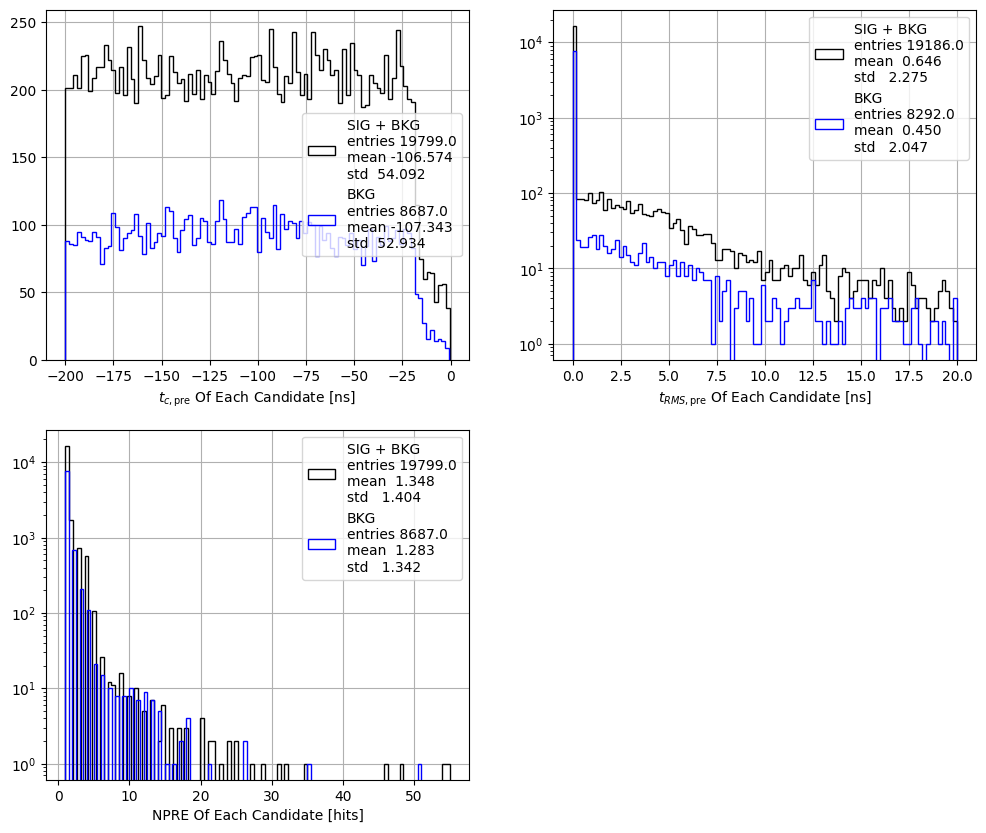

In [25]:
subplot = pltext.canvas(3)

subplot(1)
pltext.hist(tc_pre_sig, 100, xylabels=r"$t_{c, \text{pre}}$ Of Each Candidate [ns]", label="SIG + BKG");
pltext.hist(tc_pre_bkg, 100, xylabels=r"$t_{c, \text{pre}}$ Of Each Candidate [ns]", label="BKG");

subplot(2)
pltext.hist(trms_pre_sig, 100, ylog=True, xylabels=r"$t_{RMS, \text{pre}}$ Of Each Candidate [ns]", range=(0,20), label="SIG + BKG");
pltext.hist(trms_pre_bkg, 100, ylog=True, xylabels=r"$t_{RMS, \text{pre}}$ Of Each Candidate [ns]", range=(0,20), label="BKG");

subplot(3)
pltext.hist(nhits_pre_sig, 100, ylog=True, xylabels="NPRE Of Each Candidate [hits]", label="SIG + BKG");
pltext.hist(nhits_pre_bkg, 100, ylog=True, xylabels="NPRE Of Each Candidate [hits]", label="BKG");

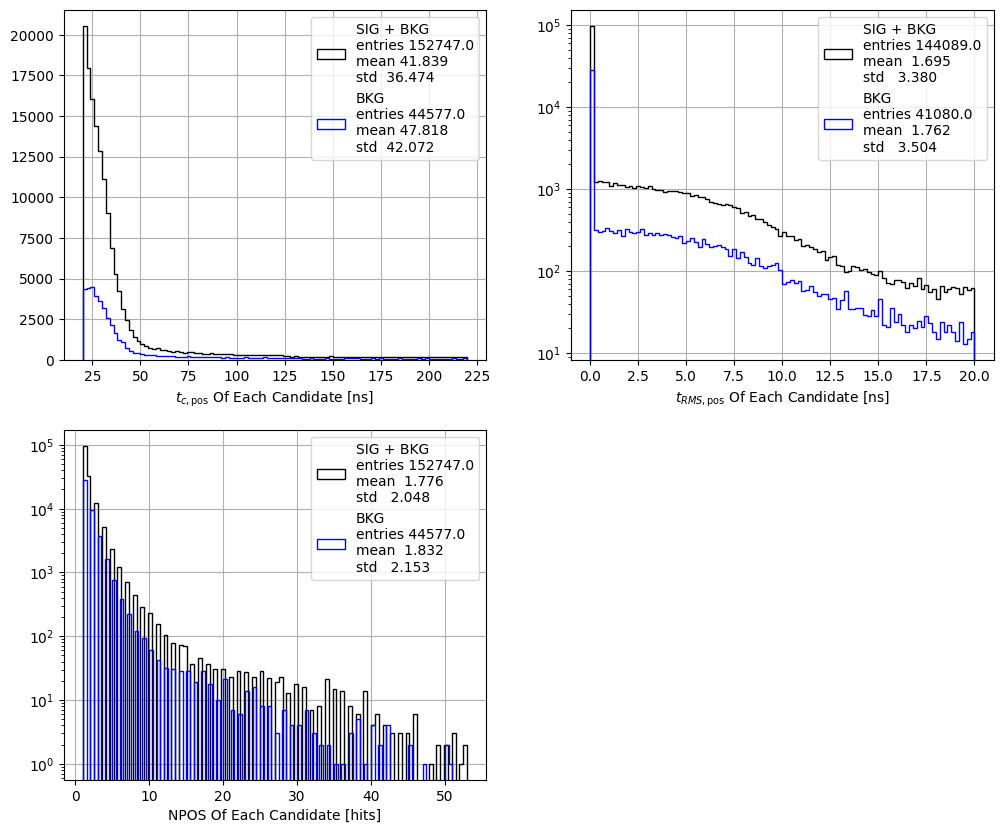

In [26]:
subplot = pltext.canvas(3)

subplot(1)
pltext.hist(tc_pos_sig, 100, xylabels=r"$t_{c, \text{pos}}$ Of Each Candidate [ns]", label="SIG + BKG");
pltext.hist(tc_pos_bkg, 100, xylabels=r"$t_{c, \text{pos}}$ Of Each Candidate [ns]", label="BKG");

subplot(2)
pltext.hist(trms_pos_sig, 100, ylog=True, xylabels=r"$t_{RMS, \text{pos}}$ Of Each Candidate [ns]", range=(0,20), label="SIG + BKG");
pltext.hist(trms_pos_bkg, 100, ylog=True, xylabels=r"$t_{RMS, \text{pos}}$ Of Each Candidate [ns]", range=(0,20), label="BKG");

subplot(3)
pltext.hist(nhits_pos_sig, 100, ylog=True, xylabels="NPOS Of Each Candidate [hits]", label="SIG + BKG");
pltext.hist(nhits_pos_bkg, 100, ylog=True, xylabels="NPOS Of Each Candidate [hits]", label="BKG");

# 2nd Purity Calculation

In [27]:
nicf_triggered_signal_hit_times_tof_clean_shifted = {
    k: [
        arr - nicf_d_seed_tof_clean[k][i]
        for i, arr in enumerate(arrays)
    ]
    for k, arrays in nicf_triggered_signal_hit_times_tof_clean.items()
    if k in nicf_d_seed_tof_clean
}

bkg_triggered_signal_hit_times_tof_clean_shifted = {
    k: [
        arr - bkg_d_seed_tof_clean[k][i]
        for i, arr in enumerate(arrays)
    ]
    for k, arrays in bkg_triggered_signal_hit_times_tof_clean.items()
    if k in bkg_d_seed_tof_clean
}

### Old Deprecated Code: Physical Bug, tc cut done in the whole candidate not the 20 ns region 

In [28]:
# nicf_triggered_signal_hit_times_tof_clean_shifted_tc = {
#     k: [arr for arr in arrays if np.mean(arr) <= 5.0]
#     for k, arrays in nicf_triggered_signal_hit_times_tof_clean_shifted.items()
# }

# bkg_triggered_signal_hit_times_tof_clean_shifted_tc = {
#     k: [arr for arr in arrays if np.mean(arr) <= 5.0]
#     for k, arrays in bkg_triggered_signal_hit_times_tof_clean_shifted.items()
# }

In [29]:
# nicf_triggered_signal_hits_index_tof_clean_tc = {}

# for k, arrays in nicf_triggered_signal_hit_times_tof_clean_shifted.items():
#     if k not in nicf_triggered_signal_hits_index_tof_clean:
#         continue

#     new_times = []
#     new_indices = []

#     for i, arr in enumerate(arrays):
#         if np.mean(arr) <= 5.0:   # ← tu corte en tc
#             new_times.append(arr)
#             new_indices.append(nicf_triggered_signal_hits_index_tof_clean[k][i])

#     nicf_triggered_signal_hit_times_tof_clean_shifted_tc[k] = new_times
#     nicf_triggered_signal_hits_index_tof_clean_tc[k]        = new_indices

# bkg_triggered_signal_hits_index_tof_clean_tc = {}

# for k, arrays in bkg_triggered_signal_hit_times_tof_clean_shifted.items():
#     if k not in bkg_triggered_signal_hits_index_tof_clean:
#         continue

#     new_times = []
#     new_indices = []

#     for i, arr in enumerate(arrays):
#         if np.mean(arr) <= 5.0:   # ← tu corte en tc
#             new_times.append(arr)
#             new_indices.append(bkg_triggered_signal_hits_index_tof_clean[k][i])

#     bkg_triggered_signal_hit_times_tof_clean_shifted_tc[k] = new_times
#     bkg_triggered_signal_hits_index_tof_clean_tc[k]        = new_indices

### New Code Physically Correct

In [30]:
def compute_tc_20(shifted_times):
    mask = (shifted_times >= 0) & (shifted_times <= 20)
    if np.any(mask):
        return np.mean(shifted_times[mask])
    return None

nicf_triggered_signal_hit_times_tof_clean_shifted_tc = {}
nicf_triggered_signal_hits_index_tof_clean_tc = {}

for k, arrays in nicf_triggered_signal_hit_times_tof_clean_shifted.items():
    if k not in nicf_triggered_signal_hits_index_tof_clean:
        continue

    new_times = []
    new_indices = []

    for i, arr in enumerate(arrays):
        tc20 = compute_tc_20(arr)

        if tc20 is not None and tc20 <= 5.0:
            new_times.append(arr)
            new_indices.append(nicf_triggered_signal_hits_index_tof_clean[k][i])

    nicf_triggered_signal_hit_times_tof_clean_shifted_tc[k] = new_times
    nicf_triggered_signal_hits_index_tof_clean_tc[k]        = new_indices

bkg_triggered_signal_hit_times_tof_clean_shifted_tc = {}
bkg_triggered_signal_hits_index_tof_clean_tc = {}

for k, arrays in bkg_triggered_signal_hit_times_tof_clean_shifted.items():
    if k not in bkg_triggered_signal_hits_index_tof_clean:
        continue

    new_times = []
    new_indices = []

    for i, arr in enumerate(arrays):
        tc20 = compute_tc_20(arr)

        if tc20 is not None and tc20 <= 5.0:
            new_times.append(arr)
            new_indices.append(bkg_triggered_signal_hits_index_tof_clean[k][i])

    bkg_triggered_signal_hit_times_tof_clean_shifted_tc[k] = new_times
    bkg_triggered_signal_hits_index_tof_clean_tc[k]        = new_indices

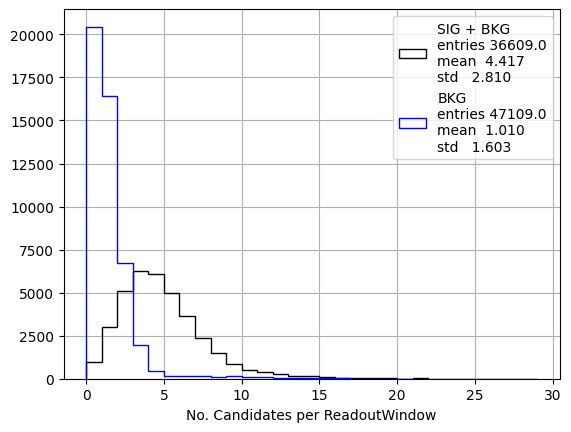

In [31]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig_clean_tc = []
for k,v in nicf_triggered_signal_hit_times_tof_clean_shifted_tc.items():
    candidates_per_redaoutWindow_sig_clean_tc.append(len(v))

candidates_per_redaoutWindow_bkg_clean_tc = []
for k,v in bkg_triggered_signal_hit_times_tof_clean_shifted_tc.items():
    candidates_per_redaoutWindow_bkg_clean_tc.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig_clean_tc, np.max(candidates_per_redaoutWindow_sig_clean_tc), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg_clean_tc, np.max(candidates_per_redaoutWindow_bkg_clean_tc), xylabels="No. Candidates per ReadoutWindow", label="BKG");

In [32]:
(3.225-0.260)/3.225*100

91.93798449612403

# $t_i - \text{ToF} - t_c$ Distribution: Off/On Time Distribution And DarkRate Calculation

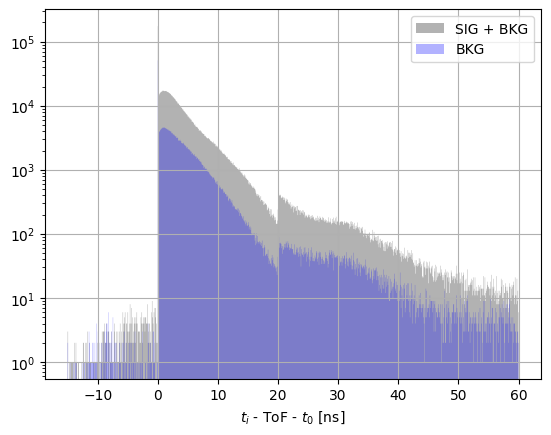

In [33]:
# Para los hits en la ventana larga calcular la distribución de t-tof-t0 de los hits. 
# A partir de la distribución a la izquierda del candidato (en el pre-trigger) podemos calcular el dark-rate, esto es, el número de hits/ns.

t_tof_tc_20_sig = {}

for k,v in nicf_triggered_signal_hit_times_tof_clean_shifted_tc.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean_shifted_tc[event] 

    t_tof_tc_20_sig[event] = []

    for i in range(len(sett)):

        shifted_sett = sett[i]

        mask  = (shifted_sett >= 0) & (shifted_sett <= 20)
        
        if np.any(mask):
            tc_20 = np.mean(shifted_sett[mask])
            t_tof_tc_20_sig[event].append(shifted_sett)

        # t_tof_tc_20_sig.append(shifted_sett)

t_tof_tc_20_bkg = {}

for k,v in bkg_triggered_signal_hit_times_tof_clean_shifted_tc.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean_shifted_tc[event]

    t_tof_tc_20_bkg[event] = []

    for i in range(len(sett)):

        shifted_sett = sett[i]

        mask  = (shifted_sett >= 0) & (shifted_sett <= 20)
        
        if np.any(mask):
            tc_20 = np.mean(shifted_sett[mask])
            t_tof_tc_20_bkg[event].append(shifted_sett)
        
        # t_tof_tc_20_bkg.append(shifted_sett)

all_sig = np.concatenate(
    [arr for sublist in t_tof_tc_20_sig.values() for arr in sublist]
)

all_bkg = np.concatenate(
    [arr for sublist in t_tof_tc_20_bkg.values() for arr in sublist]
)

hs = pltext.hist(all_sig, 1000, range=(-15, 60), ylog=True, stats=False, xylabels="$t_i$ - ToF - $t_0$ [ns]", histtype="stepfilled", alpha=0.3, label="SIG + BKG");
hb = pltext.hist(all_bkg, 1000, range=(-15, 60), ylog=True, stats=False, xylabels="$t_i$ - ToF - $t_0$ [ns]", histtype="stepfilled", alpha=0.3, label="BKG");

# plt.vlines(18.9, 0, np.max(hs[0]), color="red",   linestyles="--", label="Max. Reflection t [ns]");
# plt.vlines(9.40, 0, np.max(hs[0]), color="green", linestyles="--", label="Center To Corner [ns]");
plt.legend();

### ti - ToF - t0 Normalized to the number of candidates and Dark Rate Calculation

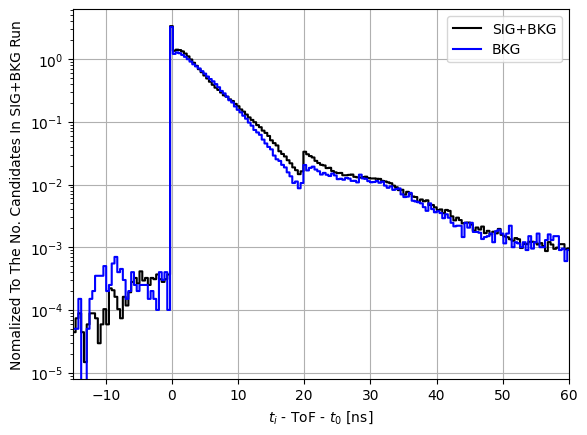

In [34]:
noCandidateSig = len([arr for sublist in t_tof_tc_20_sig.values() for arr in sublist])
noCandidateBkg = len([arr for sublist in t_tof_tc_20_bkg.values() for arr in sublist])

counts_sig, bins = np.histogram(all_sig, bins=1000, range=(-200,220))
counts_bkg, _    = np.histogram(all_bkg, bins=1000, range=(-200,220))

bin_width = bins[1] - bins[0]

# Normalizar a hits/ns/candidate
rate_sig = counts_sig / (noCandidateSig * bin_width)
rate_bkg = counts_bkg / (noCandidateBkg * bin_width)

bin_centers = 0.5*(bins[1:] + bins[:-1])

plt.step(bin_centers, rate_sig, label="SIG+BKG")
plt.step(bin_centers, rate_bkg, label="BKG")
plt.xlim(-15, 60);
plt.yscale("log")
plt.grid(True);
plt.xlabel(r"${t_i}$ - ToF - $t_0$ [ns]");
plt.ylabel("Nomalized To The No. Candidates In SIG+BKG Run");
plt.legend();

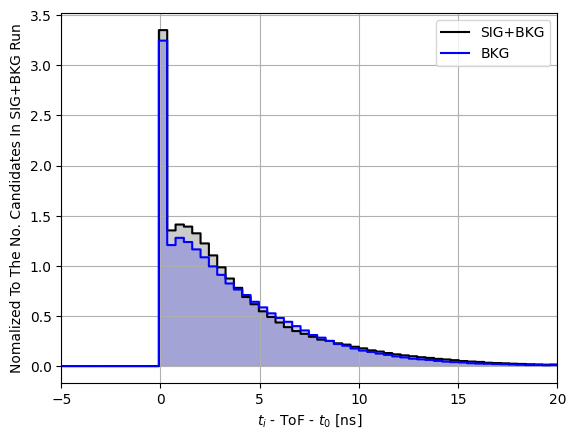

In [35]:
plt.step(bin_centers, rate_sig, where="mid", label="SIG+BKG")
plt.fill_between(bin_centers, rate_sig, step="mid", alpha=0.2)
plt.step(bin_centers, rate_bkg, where="mid", label="BKG")
plt.fill_between(bin_centers, rate_bkg, step="mid", alpha=0.2)

# plt.yscale("log")
plt.grid(True);
plt.xlim(-5, 20);
plt.xlabel(r"${t_i}$ - ToF - $t_0$ [ns]");
plt.ylabel("Nomalized To The No. Candidates In SIG+BKG Run");
plt.legend();

In [36]:
# --- Errores por bin ---
err_rate_sig = np.sqrt(counts_sig) / (noCandidateSig * bin_width)
err_rate_bkg = np.sqrt(counts_bkg) / (noCandidateBkg * bin_width)

# =========================
# PRE-TRIGGER
# =========================

mask_pre = (bin_centers >= -200) & (bin_centers <= -100)

# Media
dark_sig_pre = np.mean(rate_sig[mask_pre])
dark_bkg_pre = np.mean(rate_bkg[mask_pre])

# Error sobre la media
err_sig_pre = np.sqrt(np.sum(err_rate_sig[mask_pre]**2)) / np.sum(mask_pre)
err_bkg_pre = np.sqrt(np.sum(err_rate_bkg[mask_pre]**2)) / np.sum(mask_pre)

# Convertimos a Hz/PMT
dark_sig_hz_pre = dark_sig_pre * 1e9 / 2014
dark_bkg_hz_pre = dark_bkg_pre * 1e9 / 2014

err_sig_hz_pre = err_sig_pre * 1e9 / 2014
err_bkg_hz_pre = err_bkg_pre * 1e9 / 2014

print("Using Pre Trigger Region [-200, -100] ns")
print(f"BKG:       {dark_bkg_hz_pre:.2f} ± {err_bkg_hz_pre:.2f} Hz/PMT")
print(f"SIG + BKG: {dark_sig_hz_pre:.2f} ± {err_sig_hz_pre:.2f} Hz/PMT")


# =========================
# POST-TRIGGER
# =========================

mask_pos = (bin_centers >= 120) & (bin_centers <= 220)

dark_sig_pos = np.mean(rate_sig[mask_pos])
dark_bkg_pos = np.mean(rate_bkg[mask_pos])

err_sig_pos = np.sqrt(np.sum(err_rate_sig[mask_pos]**2)) / np.sum(mask_pos)
err_bkg_pos = np.sqrt(np.sum(err_rate_bkg[mask_pos]**2)) / np.sum(mask_pos)

dark_sig_hz_pos = dark_sig_pos * 1e9 / 2014
dark_bkg_hz_pos = dark_bkg_pos * 1e9 / 2014

err_sig_hz_pos = err_sig_pos * 1e9 / 2014
err_bkg_hz_pos = err_bkg_pos * 1e9 / 2014

print("\nUsing Post Trigger Region [120, 220] ns")
print(f"BKG:       {dark_bkg_hz_pos:.2f} ± {err_bkg_hz_pos:.2f} Hz/PMT")
print(f"SIG + BKG: {dark_sig_hz_pos:.2f} ± {err_sig_hz_pos:.2f} Hz/PMT")

Using Pre Trigger Region [-200, -100] ns
BKG:       224.47 ± 4.84 Hz/PMT
SIG + BKG: 168.39 ± 2.27 Hz/PMT

Using Post Trigger Region [120, 220] ns
BKG:       302.88 ± 5.62 Hz/PMT
SIG + BKG: 324.83 ± 3.16 Hz/PMT


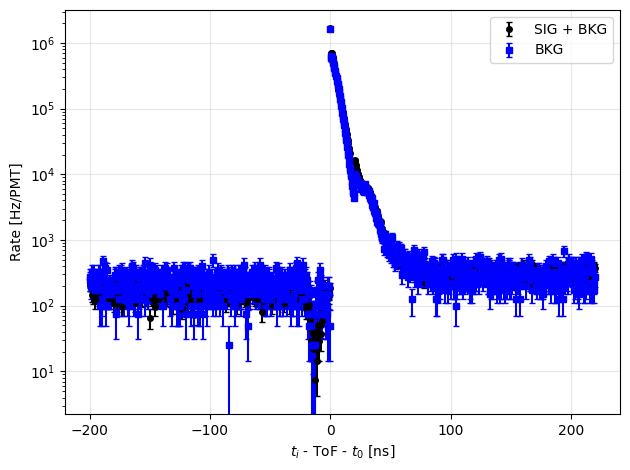

In [37]:
rate_sig_hz = rate_sig * 1e9 / 2014
rate_bkg_hz = rate_bkg * 1e9 / 2014

err_sig_hz  = err_rate_sig * 1e9 / 2014
err_bkg_hz  = err_rate_bkg * 1e9 / 2014

plt.figure()

# SIG + BKG
plt.errorbar(
    bin_centers,
    rate_sig_hz,
    yerr=err_sig_hz,
    fmt='o',
    markersize=4,
    capsize=2,
    label="SIG + BKG"
)

# BKG
plt.errorbar(
    bin_centers,
    rate_bkg_hz,
    yerr=err_bkg_hz,
    fmt='s',
    markersize=4,
    capsize=2,
    label="BKG"
)

plt.yscale("log")
plt.xlabel("$t_i$ - ToF - $t_0$ [ns]")
plt.ylabel("Rate [Hz/PMT]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()


### Create PDF of the ti - ToF - t0 Distributions and Subtract

In [38]:
hs = np.histogram(all_sig, bins=bins)
hb = np.histogram(all_bkg, bins=bins)

bin_centers = (hs[1][:-1] + hs[1][1:]) / 2
pdf_sig = hs[0] / np.sum(hs[0])
pdf_bkg = hb[0] / np.sum(hb[0])

err_sig = np.sqrt(hs[0]) / np.sum(hs[0])
err_bkg = np.sqrt(hb[0]) / np.sum(hb[0])

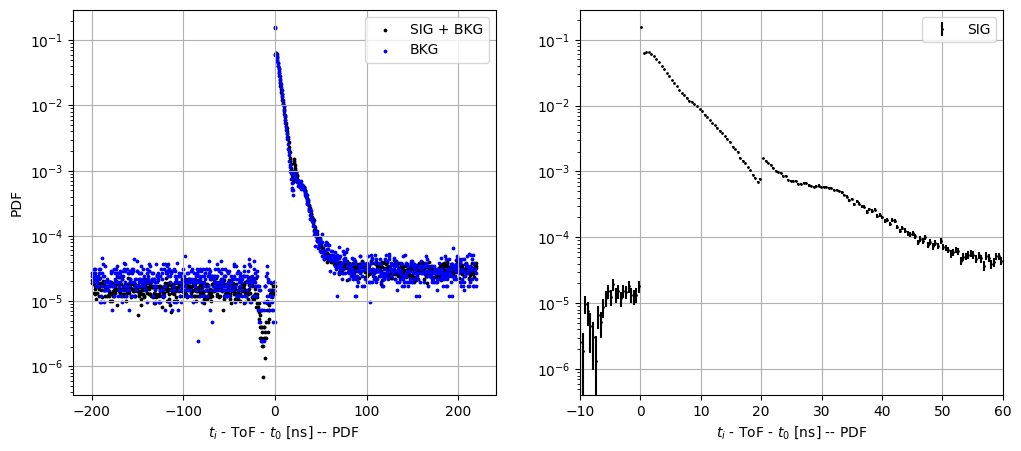

In [39]:
subplot = pltext.canvas(2)


subplot(1)
# PDF SIG/BKG
plt.scatter(bin_centers, pdf_sig, s=3, label="SIG + BKG")
plt.scatter(bin_centers, pdf_bkg, s=3, label="BKG")
plt.xlabel("$t_i$ - ToF - $t_0$ [ns] -- PDF")
plt.ylabel("PDF")
plt.grid(True)
plt.yscale("log")
plt.legend();


subplot(2)
# Diferencia SIG-BKG
diff = (pdf_sig - pdf_bkg*0.1)/0.9
diff_err = (1/0.9) * np.sqrt(err_sig**2 + (0.1**2) * err_bkg**2)
plt.errorbar(bin_centers, diff, yerr=diff_err, fmt='o', markersize=1, label="SIG")
plt.xlabel("$t_i$ - ToF - $t_0$ [ns] -- PDF");
plt.yscale("log");
plt.grid(True);
plt.xlim(-10, 60);
plt.legend();

In [40]:
bins = np.concatenate([
    np.arange(-200, 0, 5),     # antes de 0 → 5 ns
    np.arange(0, 20, 1),      # 0–20 → 1 ns
    np.arange(20, 220, 5)      # después de 20 → 5 ns
])
bins = np.unique(bins)

hs = np.histogram(all_sig, bins=bins)
hb = np.histogram(all_bkg, bins=bins)

bin_centers = (hs[1][:-1] + hs[1][1:]) / 2
bin_widths = np.diff(hs[1])

# La definición de PDF cambia. Ahora hay que dividir entre el ancho del bin.
pdf_sig = hs[0] / (np.sum(hs[0]) * bin_widths)
pdf_bkg = hb[0] / (np.sum(hb[0]) * bin_widths)

err_sig = np.sqrt(hs[0]) / (np.sum(hs[0]) * bin_widths)
err_bkg = np.sqrt(hb[0]) / (np.sum(hb[0]) * bin_widths)

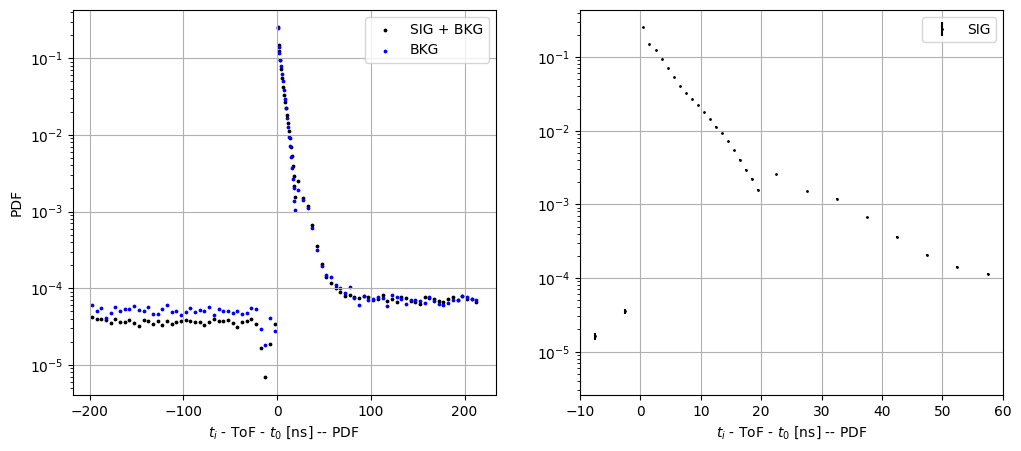

In [41]:
subplot = pltext.canvas(2)

subplot(1)
# PDF SIG/BKG
plt.scatter(bin_centers, pdf_sig, s=3, label="SIG + BKG")
plt.scatter(bin_centers, pdf_bkg, s=3, label="BKG")
plt.xlabel("$t_i$ - ToF - $t_0$ [ns] -- PDF")
plt.ylabel("PDF")
plt.grid(True)
plt.yscale("log")
plt.legend();


subplot(2)
# Diferencia SIG-BKG
diff = (pdf_sig - pdf_bkg*0.1)/0.9
diff_err = (1/0.9) * np.sqrt(err_sig**2 + (0.1**2) * err_bkg**2)
plt.errorbar(bin_centers, diff, yerr=diff_err, fmt='o', markersize=1, label="SIG")
plt.xlabel("$t_i$ - ToF - $t_0$ [ns] -- PDF");
plt.yscale("log");
plt.grid(True);
plt.xlim(-10, 60);
plt.legend();

# Filtering Using On Time Region Too

In [42]:
def createDataFrame(triggered_signal_hits_index_tof_clean_tc, times, charg, slots, poids, t_tof_tc_20, inf_time, sup_time):
    rows = []
    candidate_global_id = 0  # ID único por candidato

    for event in tqdm(triggered_signal_hits_index_tof_clean_tc.keys()):

        candidates_idx   = triggered_signal_hits_index_tof_clean_tc[event]
        candidates_times = t_tof_tc_20.get(event, [])

        for cand_times_shifted, cand_indices in zip(candidates_times, candidates_idx):

            # Seguridad: misma longitud
            if len(cand_times_shifted) != len(cand_indices):
                continue

            # Corte on-time en tiempos shifteados a tc
            mask = (cand_times_shifted > inf_time) & (cand_times_shifted < sup_time)

            if not np.any(mask):
                continue

            selected_indices = cand_indices[mask]
            selected_times_shifted_tc = cand_times_shifted[mask]

            # Acceso a datos originales
            selected_times     = times[event][selected_indices]
            selected_charges   = charg[event][selected_indices]
            selected_slots     = slots[event][selected_indices]
            selected_positions = poids[event][selected_indices]

            for t, c, s, p, t_shift in zip(selected_times,
                                        selected_charges,
                                        selected_slots,
                                        selected_positions,
                                        selected_times_shifted_tc):

                rows.append([
                    candidate_global_id,   # ← ID de candidato (no de evento)
                    event,                 # opcional, útil para debug
                    float(t),
                    float(c),
                    int(s),
                    int(p),
                    float(t_shift)
                ])

            candidate_global_id += 1  # incrementa SOLO al cambiar de candidato

    df = pd.DataFrame(rows, columns=[
        "candidate_id",
        "event_id",            # puedes borrarla si no la quieres
        "hit_pmt_calibrated_times",
        "hit_pmt_charges",
        "hit_mpmt_slot_ids",
        "hit_pmt_position_ids",
        "time_shifted_tc"
    ])

    df["pmt_id"] = df["hit_mpmt_slot_ids"]*19 + df["hit_pmt_position_ids"]

    return df

In [43]:
df_sig = createDataFrame(nicf_triggered_signal_hits_index_tof_clean_tc, nicf_run_tof_corrected_times, nicf_run_tof_hit_charges, nicf_run_tof_hit_slot_ids, nicf_run_tof_hit_position_ids, t_tof_tc_20_sig, 0, 15)
df_bkg = createDataFrame(bkg_triggered_signal_hits_index_tof_clean_tc, bkg_run_corrected_times, bkg_run_hit_charges, bkg_run_hit_slot_ids, bkg_run_hit_position_ids, t_tof_tc_20_bkg, 0, 15)
df_sig_pre = createDataFrame(nicf_triggered_signal_hits_index_tof_clean_tc, nicf_run_tof_corrected_times, nicf_run_tof_hit_charges, nicf_run_tof_hit_slot_ids, nicf_run_tof_hit_position_ids, t_tof_tc_20_sig, -200, -100)
df_sig_pos = createDataFrame(nicf_triggered_signal_hits_index_tof_clean_tc, nicf_run_tof_corrected_times, nicf_run_tof_hit_charges, nicf_run_tof_hit_slot_ids, nicf_run_tof_hit_position_ids, t_tof_tc_20_sig, 120, 220)
df_bkg_pre = createDataFrame(bkg_triggered_signal_hits_index_tof_clean_tc, bkg_run_corrected_times, bkg_run_hit_charges, bkg_run_hit_slot_ids, bkg_run_hit_position_ids, t_tof_tc_20_bkg, -200, -100)
df_bkg_pos = createDataFrame(bkg_triggered_signal_hits_index_tof_clean_tc, bkg_run_corrected_times, bkg_run_hit_charges, bkg_run_hit_slot_ids, bkg_run_hit_position_ids, t_tof_tc_20_bkg, 120, 220)

100%|██████████| 47109/47109 [00:02<00:00, 18975.76it/s]


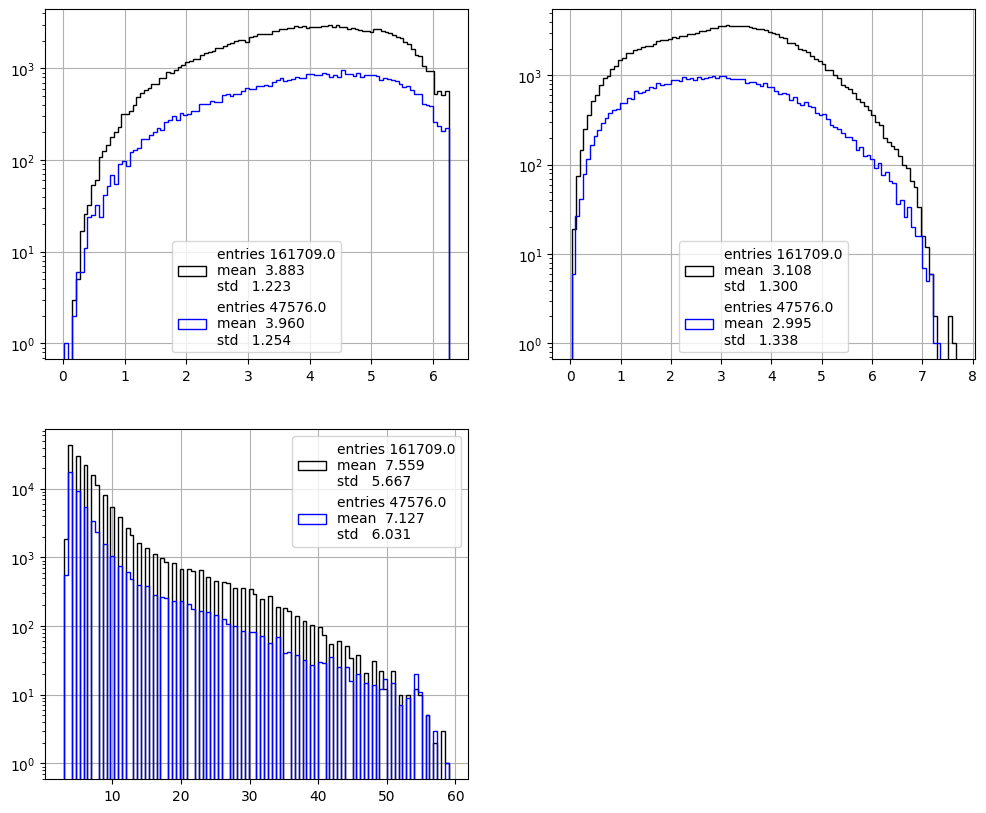

In [44]:
subplot = pltext.canvas(3)

subplot(1)
mean_time_sig = df_sig.groupby("candidate_id")["time_shifted_tc"].mean().values
mean_time_bkg = df_bkg.groupby("candidate_id")["time_shifted_tc"].mean().values
pltext.hist(mean_time_sig, 100, ylog=True);
pltext.hist(mean_time_bkg, 100, ylog=True);

subplot(2)
std_time_sig = df_sig.groupby("candidate_id")["time_shifted_tc"].std().values
std_time_bkg = df_bkg.groupby("candidate_id")["time_shifted_tc"].std().values
pltext.hist(std_time_sig, 100, ylog=True);
pltext.hist(std_time_bkg, 100, ylog=True);

subplot(3)
nhits_sig = df_sig.groupby("candidate_id")["time_shifted_tc"].count().values
nhits_bkg = df_bkg.groupby("candidate_id")["time_shifted_tc"].count().values
pltext.hist(nhits_sig, 100, ylog=True);
pltext.hist(nhits_bkg, 100, ylog=True);

In [45]:
(len(df_sig["candidate_id"].unique()) - len(df_bkg["candidate_id"].unique()))/len(df_sig["candidate_id"].unique())*100

70.57925038185877

In [46]:
# df_sig.to_csv("data_files/otm&brm_1767.csv")
# df_bkg.to_csv("data_files/otm&brm_1766.csv")

# Compute QE

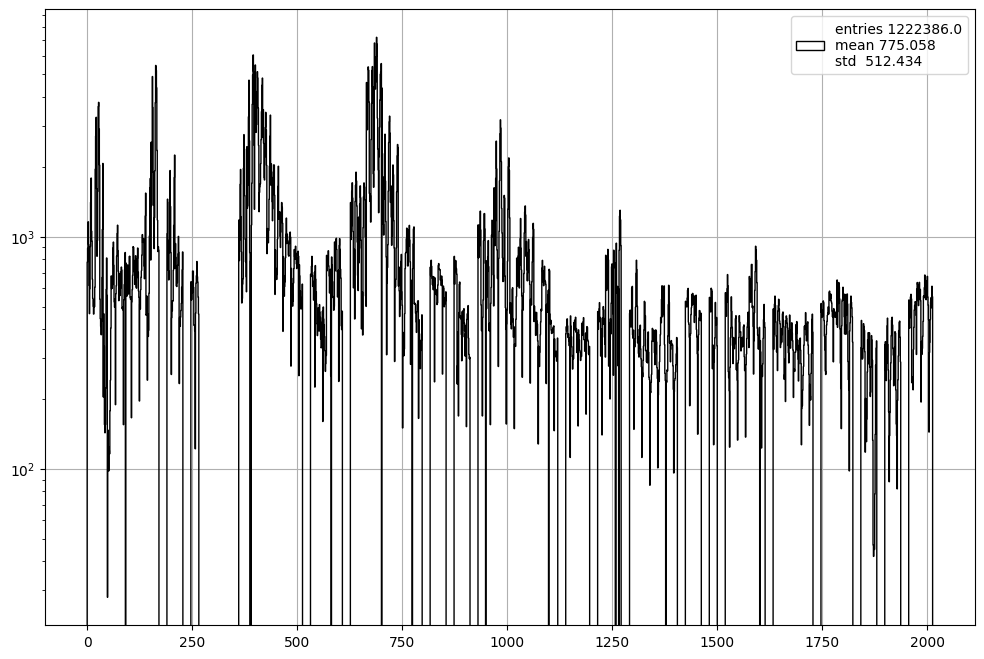

In [47]:
fig = plt.figure(figsize=(12, 8))

pltext.hist(df_sig["pmt_id"], 2014, ylog=True);

## Read MC Data

In [48]:
from WCSimFilePackages.npz_to_df import simple_truehits_info_to_df, digihits_info_to_df

npz_down = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1767_CDSON_15kevents.npz'
nevents  = 15000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_down = simple_truehits_info_to_df(npz_down).dropna()
df_digiHits_down = digihits_info_to_df(npz_down, nevents).dropna()

In [49]:
from WCTE_event_display.EventDisplay      import EventDisplay

#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")

In [50]:
import json

# Cargar los datos de gaps del análisis anterior
with open('/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim_old/install/npz/gap_analysis_data.json', 'r') as f:
    gap_data = json.load(f)
    
invalid_pmt_id = []
for i in range(len(gap_data["gaps_detalle"])):
    invalid_pmt_id.append(gap_data["gaps_detalle"][i]["numeros_faltantes"])

invalid_pmt_id = np.concatenate(invalid_pmt_id)

In [51]:
no_candidates_sig = df_sig.candidate_id.nunique()
no_candidates_mc  = df_digiHits_down.event_id.nunique()

print(no_candidates_mc, no_candidates_sig)

14935 161709


In [52]:
mc = df_digiHits_down
tube_no = mc["digi_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

df_digiHits_down["pmt_id"] = mc_pmt_id

mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

print(len(mc["event_id"].unique()))

[40 40 40 ... 53 51 51]
14935


In [53]:
ps = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].sum().index.to_numpy(dtype=int)
cs = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].sum().to_numpy()
count = df_digiHits_down.groupby("pmt_id")["digi_hit_charge"].count().to_numpy()
mcss = np.zeros(2014)
mcss[ps] = cs
countmc = np.zeros(2014)
countmc[ps] = count

In [54]:
pmts_sig = df_sig["pmt_id"]

sig_hits_per_pmt = np.bincount(
    pmts_sig.astype(int),
    minlength=2014
)

pure_signal = sig_hits_per_pmt

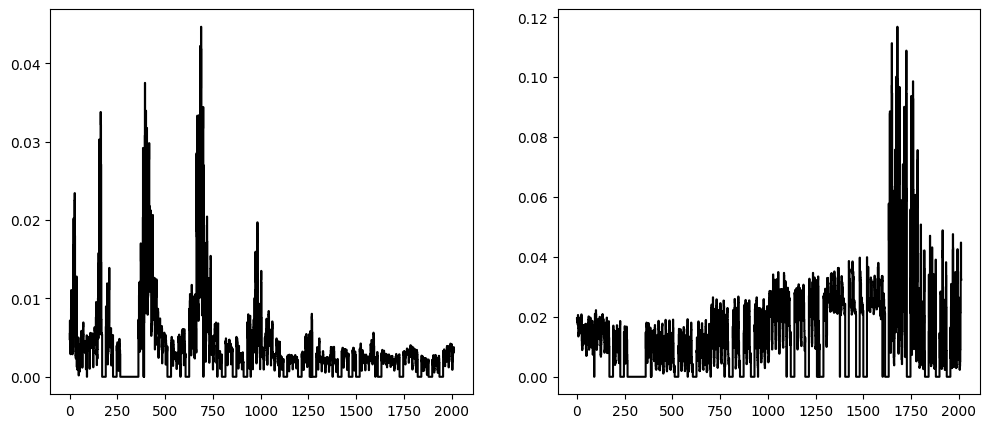

In [55]:
subplot = pltext.canvas(2)

subplot(1)
plt.step(range(2014), pure_signal/no_candidates_sig);

subplot(2)
mc_signal = np.bincount(mc_pmt_id, minlength=2014)

plt.step(range(2014), mc_signal/no_candidates_mc);

## Compare Data VS. MC

#### RQE

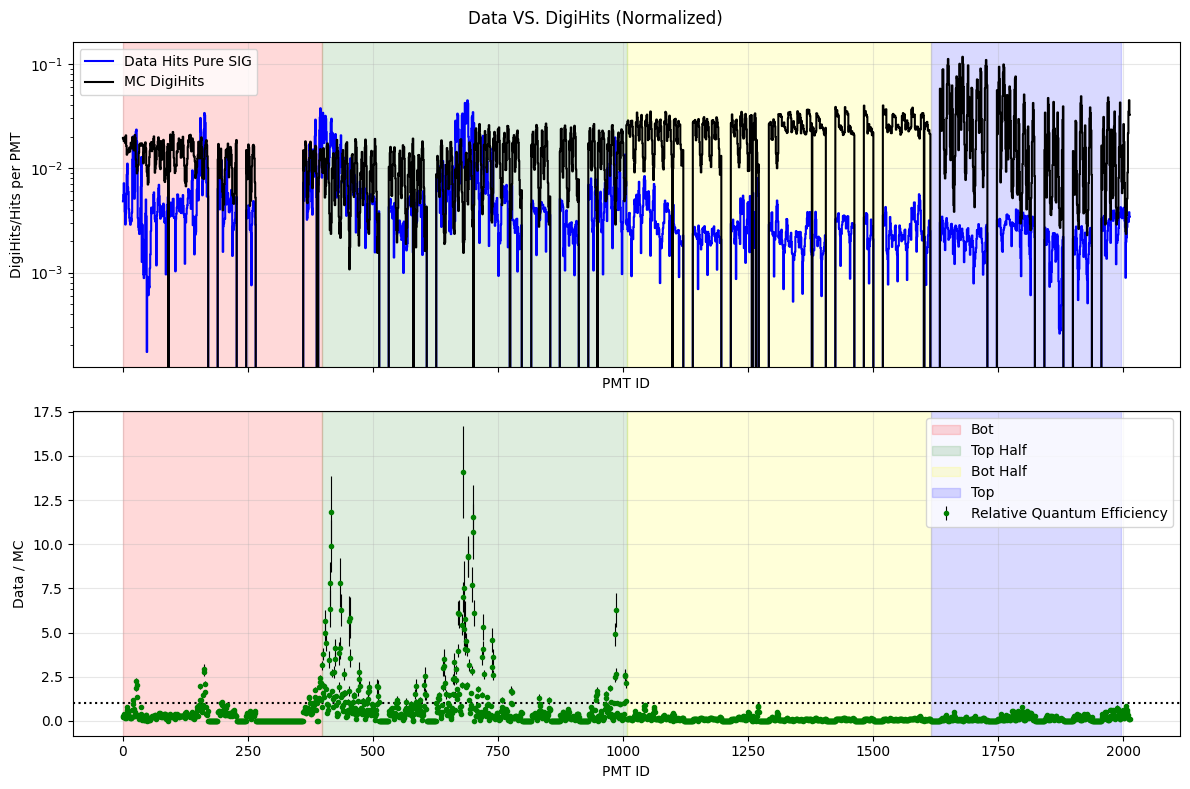

In [56]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

# --- DigiHits por PMT ---
ax1.step(range(2014), pure_signal/no_candidates_sig,    where="mid", color="blue",  label="Data Hits Pure SIG")
ax1.step(range(2014), mc_signal/no_candidates_mc, where="mid", color="black", label="MC DigiHits")

ax1.set_yscale("log")
ax1.set_ylabel("DigiHits/Hits per PMT")
ax1.set_xlabel("PMT ID")
ax1.axvspan(0, 21*19,      color="red",         alpha=0.15)
ax1.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax1.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15)
ax1.axvspan(85*19, 105*19, color="blue",        alpha=0.15)
ax1.legend()
ax1.grid(alpha=0.3)

# --- Hits por PMT normalizados ---
N_data = pure_signal          # conteos por PMT
N_mc   = mc_signal            # conteos por PMT

data_hits_per_pmt = N_data / no_candidates_sig
mc_hits_per_pmt   = N_mc   / no_candidates_mc

# --- Errores Poissonianos por bin ---
error_data = np.zeros(2014)
error_mc   = np.zeros(2014)

mask_data = N_data > 0
mask_mc   = N_mc   > 0

error_data[mask_data] = np.sqrt(N_data[mask_data]) / no_candidates_sig
error_mc[mask_mc]     = np.sqrt(N_mc[mask_mc])   / no_candidates_mc

# --- Ratio Data / MC y su error ---
relative_qe       = np.zeros(2014)
error_relative_qe = np.zeros(2014)

mask = (mc_hits_per_pmt > 0) & (data_hits_per_pmt > 0)

relative_qe[mask] = data_hits_per_pmt[mask] / mc_hits_per_pmt[mask]

error_relative_qe[mask] = np.sqrt(
    (error_data[mask] / mc_hits_per_pmt[mask])**2
    +
    (data_hits_per_pmt[mask] * error_mc[mask] / mc_hits_per_pmt[mask]**2)**2
)

ax2.errorbar(
    range(2014),
    relative_qe,
    yerr=error_relative_qe,
    fmt="o",
    markersize=3,
    markerfacecolor="green",
    markeredgecolor="green",
    ecolor="black",        # color de las barras de error
    elinewidth=0.8,
    capsize=0,
    label="Relative Quantum Efficiency"
)
# ax2.scatter(range(2014), relative_qe, color="green", s=2, label="Relative Quantum Efficiency", zorder=2)
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT ID")
ax2.grid(alpha=0.3)
# ax2.set_ylim(-2, 4)
plt.legend()

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red",         alpha=0.15, label="Bot")
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15, label="Top Half")
ax2.axvspan(53*19, 85*19,  color="yellow",      alpha=0.15, label="Bot Half")
ax2.axvspan(85*19, 105*19, color="blue",        alpha=0.15, label="Top")
ax2.legend()

plt.suptitle("Data VS. DigiHits (Normalized)", y=0.98)
plt.tight_layout()

# Desplegables

(2014,)


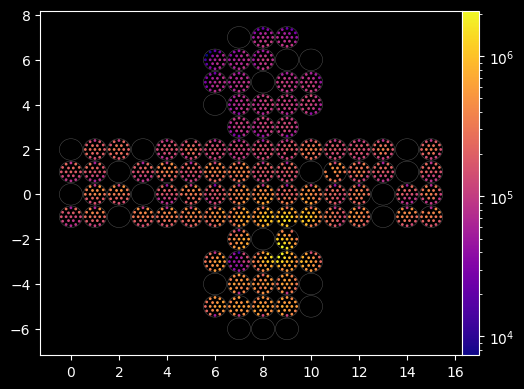

In [57]:
# The standard way to use the EventDisplay
# Charge is not calibrated for the moment though, so I prefer using nHits

import matplotlib.colors as colors

data_to_plot = df_sig["hit_pmt_charges"]

#map from the tube number to the mPMT slot and position number
data_to_plot = eventDisplay.process_data(df_sig["hit_mpmt_slot_ids"], df_sig["hit_pmt_position_ids"], data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

(2014,)
(2014,)
(2014,)
(2014,)
(2014,)
(2014,)


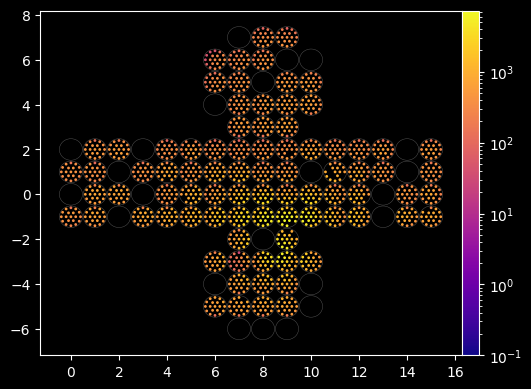

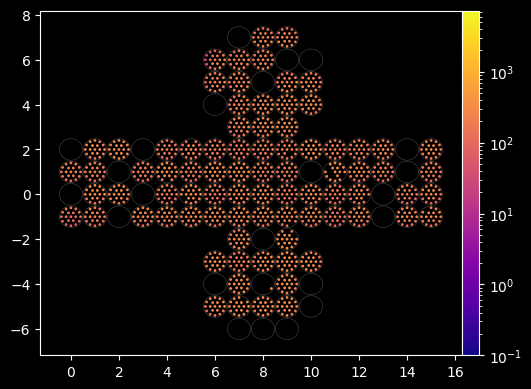

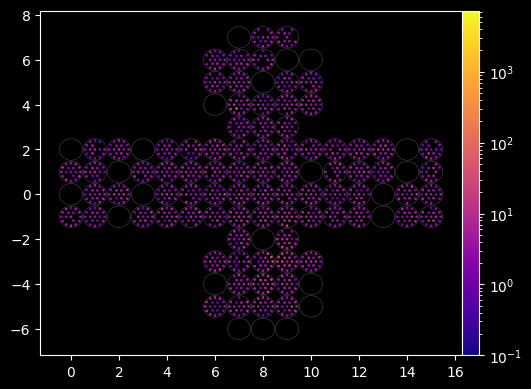

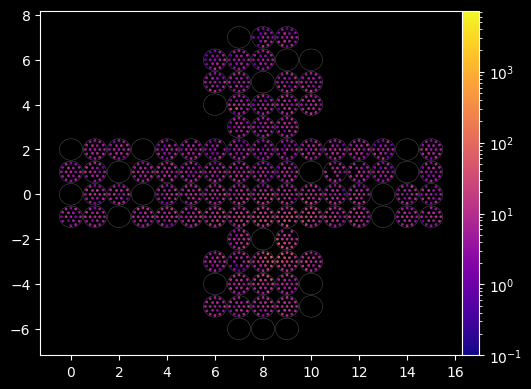

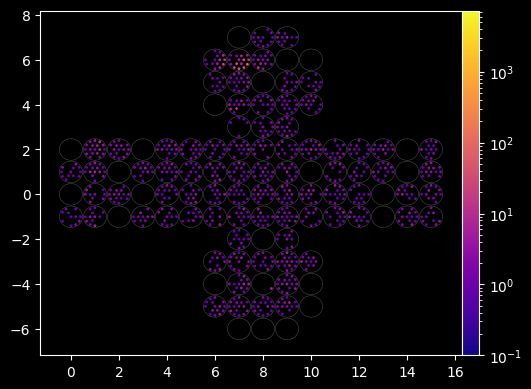

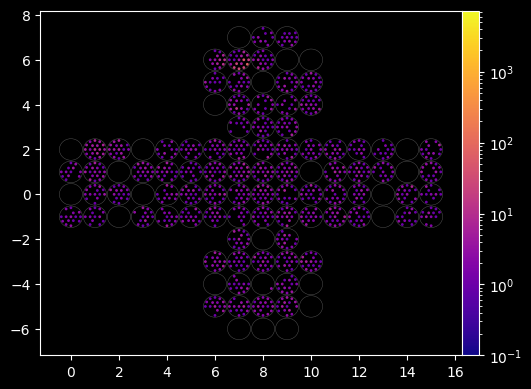

In [58]:
import matplotlib.colors as colors

n_pmts = 2014

# --- Calculamos la escala global según df_sig ---
nhits_sig = df_sig.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=np.nan).values
nhits_sig = np.nan_to_num(nhits_sig, nan=0.0)
vmax = np.nanmax(nhits_sig)
vmin = 1e-1  # mínimo positivo para LogNorm (evitar log(0))

# --- df_sig ---
eventDisplay.plotEventDisplay(
    nhits_sig,
    color_norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# --- df_bkg ---
nhits_bkg = df_bkg.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_bkg,
    color_norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# --- df_sig_pre ---
nhits_pre = df_sig_pre.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_pre,
    color_norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# --- df_sig_pos ---
nhits_pos = df_sig_pos.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_pos,
    color_norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# --- df_bkg_pre ---
nhits_pre = df_bkg_pre.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_pre,
    color_norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# --- df_bkg_pos ---
nhits_pos = df_bkg_pos.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_pos,
    color_norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    style="dark_background"
)

plt.style.use('default');
pltext.style()

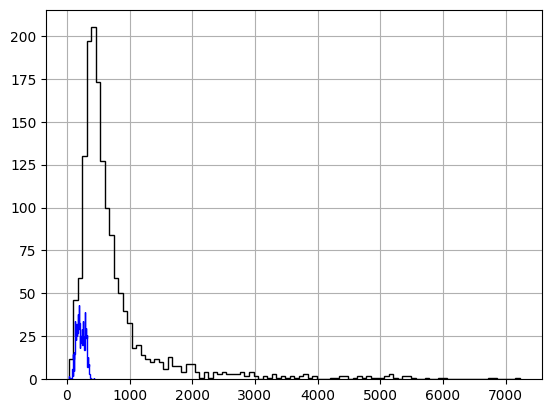

In [59]:
pltext.hist(df_sig.groupby("pmt_id")["hit_pmt_charges"].count(), 100, stats=False);
pltext.hist(df_bkg.groupby("pmt_id")["hit_pmt_charges"].count(), 100, stats=False);

In [60]:
len(pdf_sig)

99

In [61]:
hs = np.histogram(df_sig.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=np.nan).values, bins=2014)
hb = np.histogram(df_bkg.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=np.nan).values, bins=2014)

bin_centers = (hs[1][:-1] + hs[1][1:]) / 2
pdf_sig = hs[0] / np.sum(hs[0])
pdf_bkg = hb[0] / np.sum(hb[0])

# Errores Poisson
err_sig = np.sqrt(hs[0]) / np.sum(hs[0])
err_bkg = np.sqrt(hb[0]) / np.sum(hb[0])

subplot = pltext.canvas(2)
# PDF SIG/BKG
subplot(1)
plt.scatter(bin_centers, pdf_sig, s=3, label="SIG + BKG")
plt.scatter(bin_centers, pdf_bkg, s=3, label="BKG")
plt.xlabel("anything")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

# Diferencia SIG-BKG
subplot(2)
diff = (pdf_sig - pdf_bkg*0.1)/0.9
diff_err = (1/0.9) * np.sqrt(err_sig**2 + (0.1**2) * err_bkg**2)
plt.errorbar(bin_centers, diff, yerr=diff_err, fmt='o', markersize=1, label="SIG-BKG");

ValueError: autodetected range of [nan, nan] is not finite

(2014,)


ValueError: 'c' argument has 100 elements, which is inconsistent with 'x' and 'y' with size 2014.

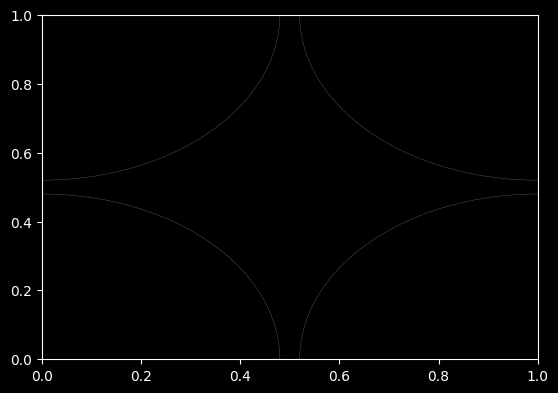

In [ ]:
vmax = np.nanmax(diff)
vmin = 1e-1  # mínimo positivo para LogNorm (evitar log(0))

# --- df_sig ---
eventDisplay.plotEventDisplay(
    diff,
    color_norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# Charge Distribution Per PMT

In [ ]:
df_sig.describe()

,candidate_id,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,time_shifted_tc,pmt_id
count,1.222386e+06,1.222386e+06,1.222386e+06,1.222386e+06,1.222386e+06,1.222386e+06,1.222386e+06,1.222386e+06
mean,8.088810e+04,1.828683e+04,2.012716e+05,3.523496e+02,4.033327e+01,8.725886e+00,3.931133e+00,7.750580e+02
std,4.672874e+04,1.061634e+04,1.387032e+05,6.056836e+02,2.696290e+01,5.701719e+00,3.306360e+00,5.124338e+02
min,0.000000e+00,0.000000e+00,-4.694880e+02,6.000000e+00,0.000000e+00,0.000000e+00,7.993018e-06,0.000000e+00
25%,4.028800e+04,8.932000e+03,8.108802e+04,1.240000e+02,2.100000e+01,4.000000e+00,1.408654e+00,4.060000e+02
50%,8.107400e+04,1.841400e+04,1.794430e+05,1.670000e+02,3.600000e+01,8.000000e+00,2.948249e+00,6.860000e+02
75%,1.210460e+05,2.716800e+04,3.081474e+05,2.570000e+02,5.500000e+01,1.400000e+01,5.567126e+00,1.052000e+03
max,1.617080e+05,3.660800e+04,5.031500e+05,8.150000e+03,1.050000e+02,1.800000e+01,1.499998e+01,2.013000e+03


In [ ]:
def plotCharges(df):
    subplot = pltext.canvas(19)
    for pmt in range(19):
        charge = df[df["pmt_id"].values == pmt]["hit_pmt_charges"].values
        subplot(pmt+1)
        pltext.hist(charge, 100, range=(0, 1e3), stats=False, xylabels=f"Hit Charge In PMT #{pmt} [ADC]");


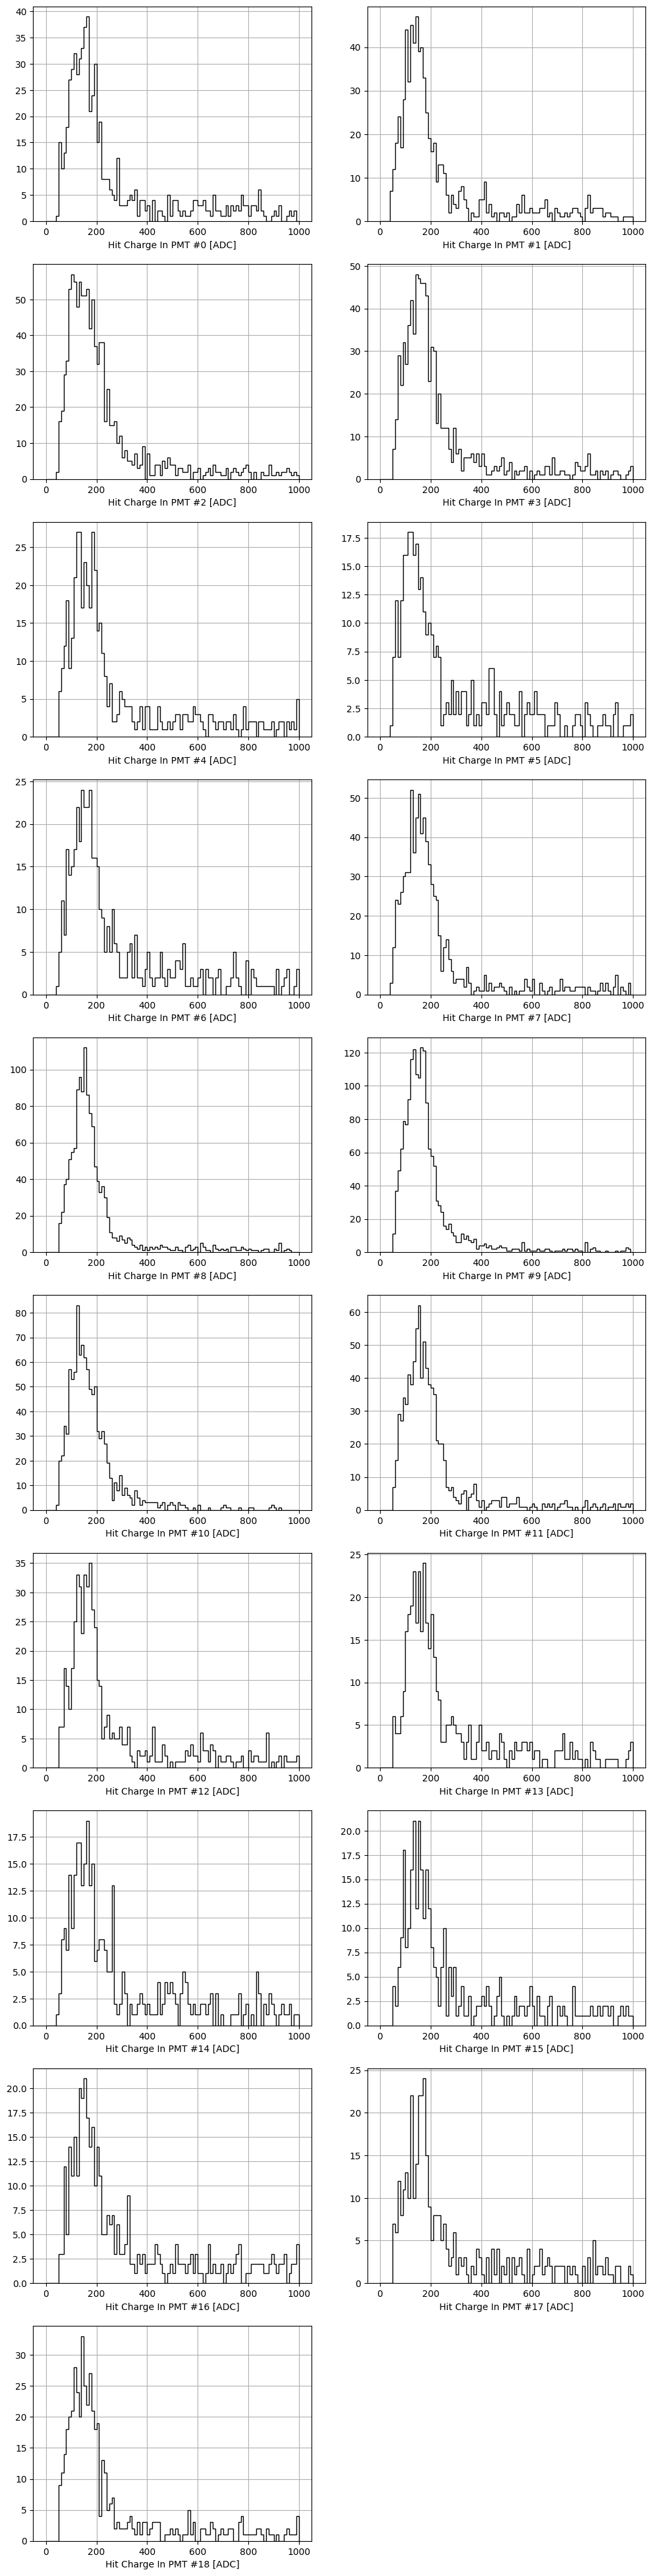

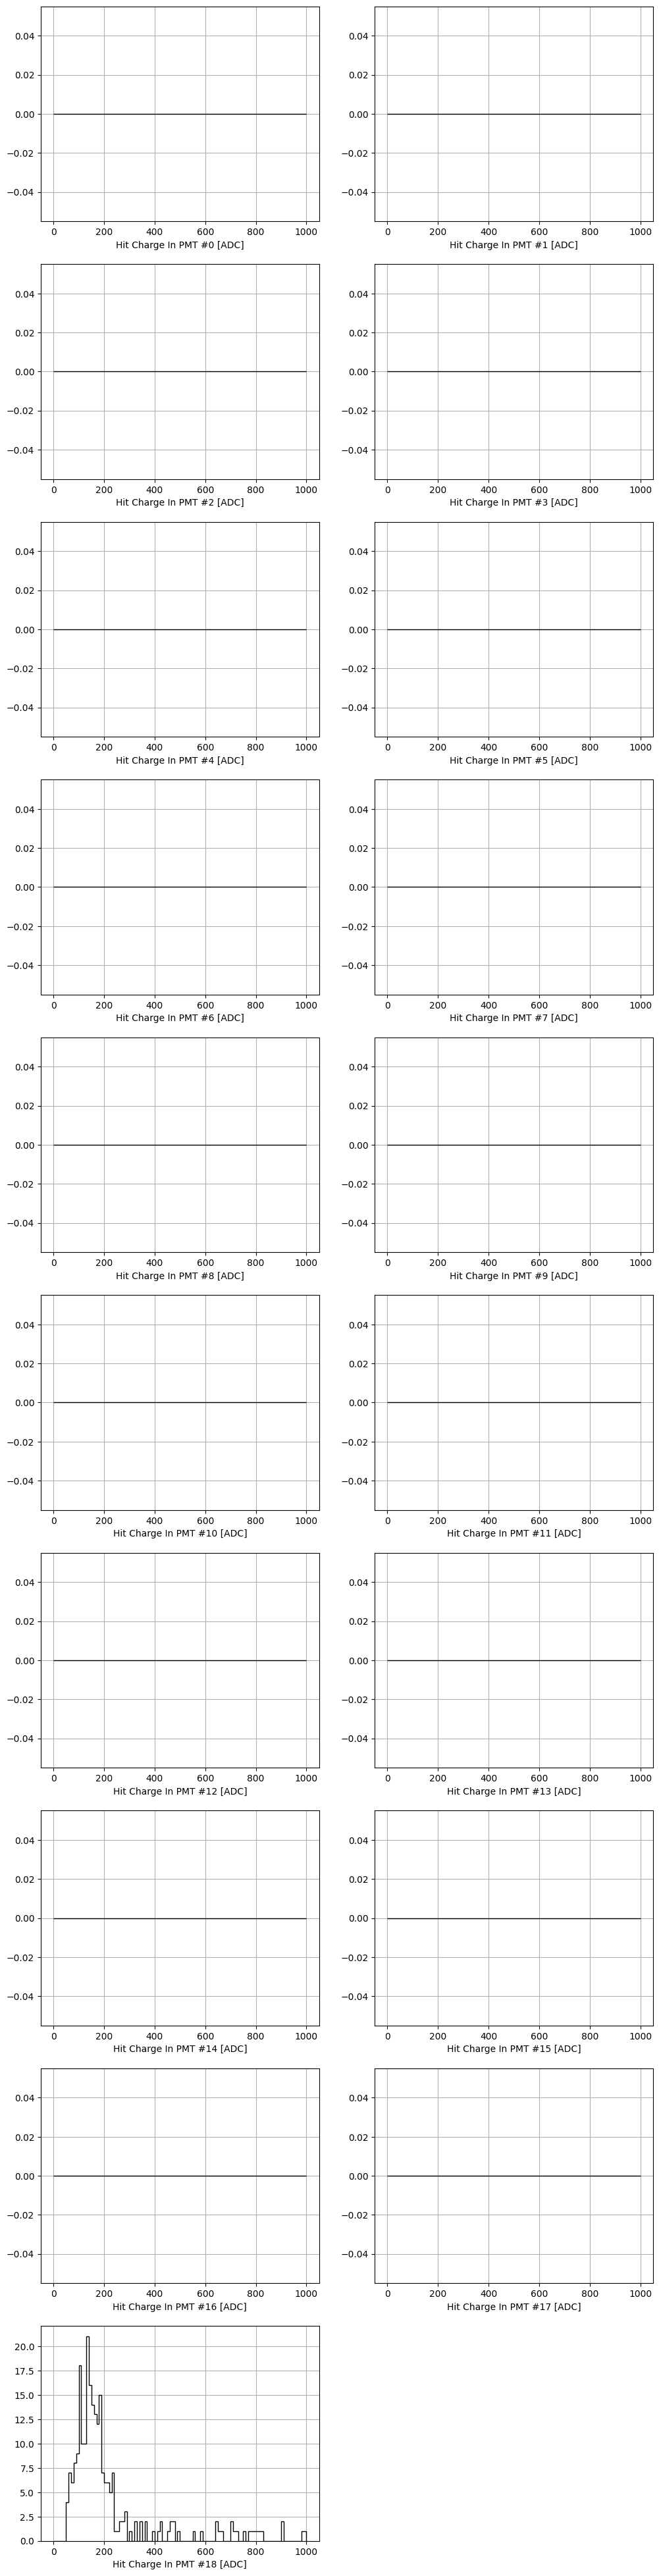

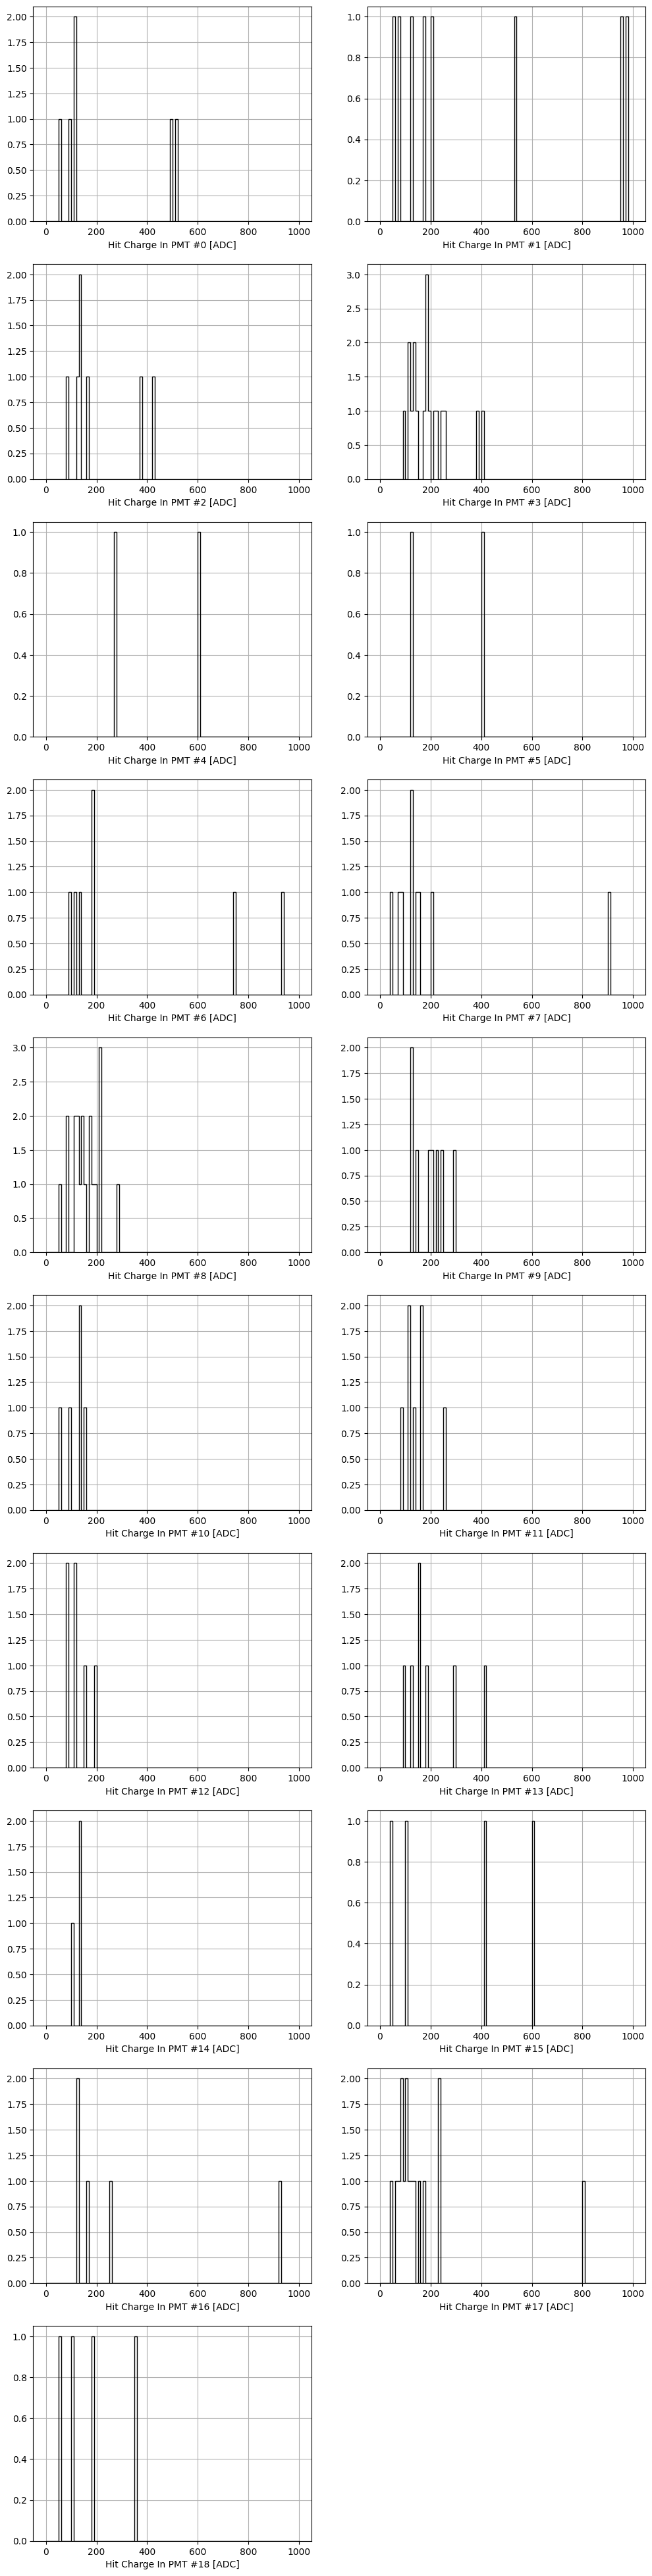

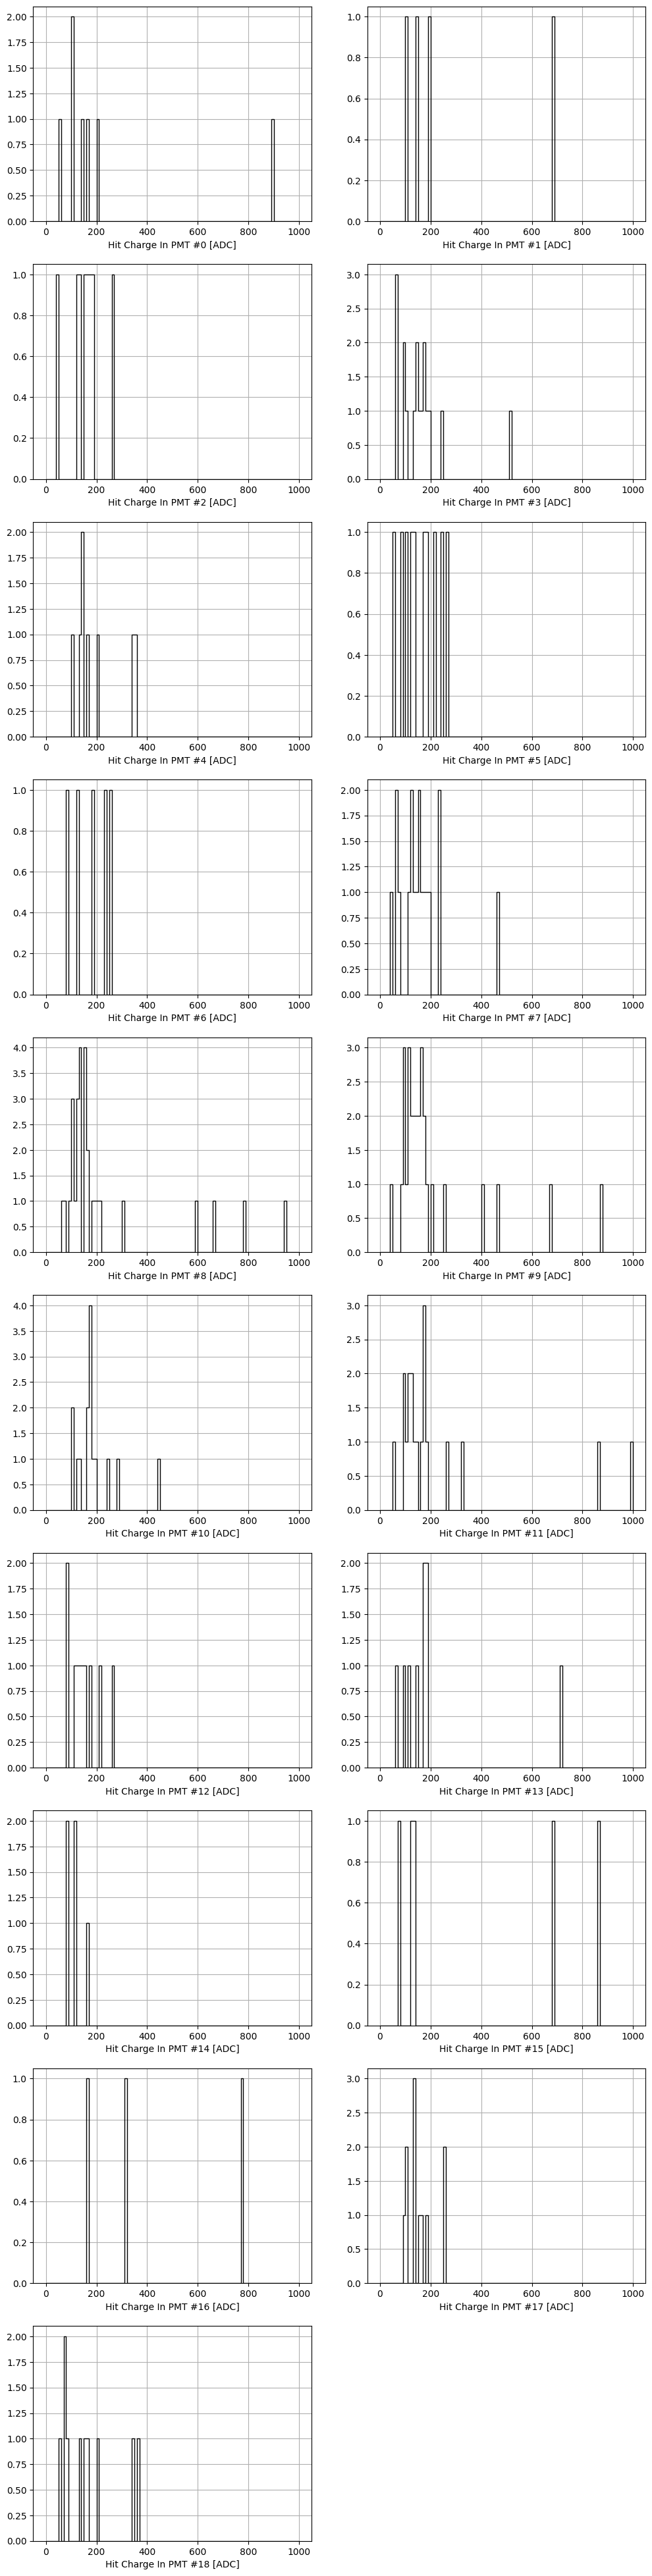

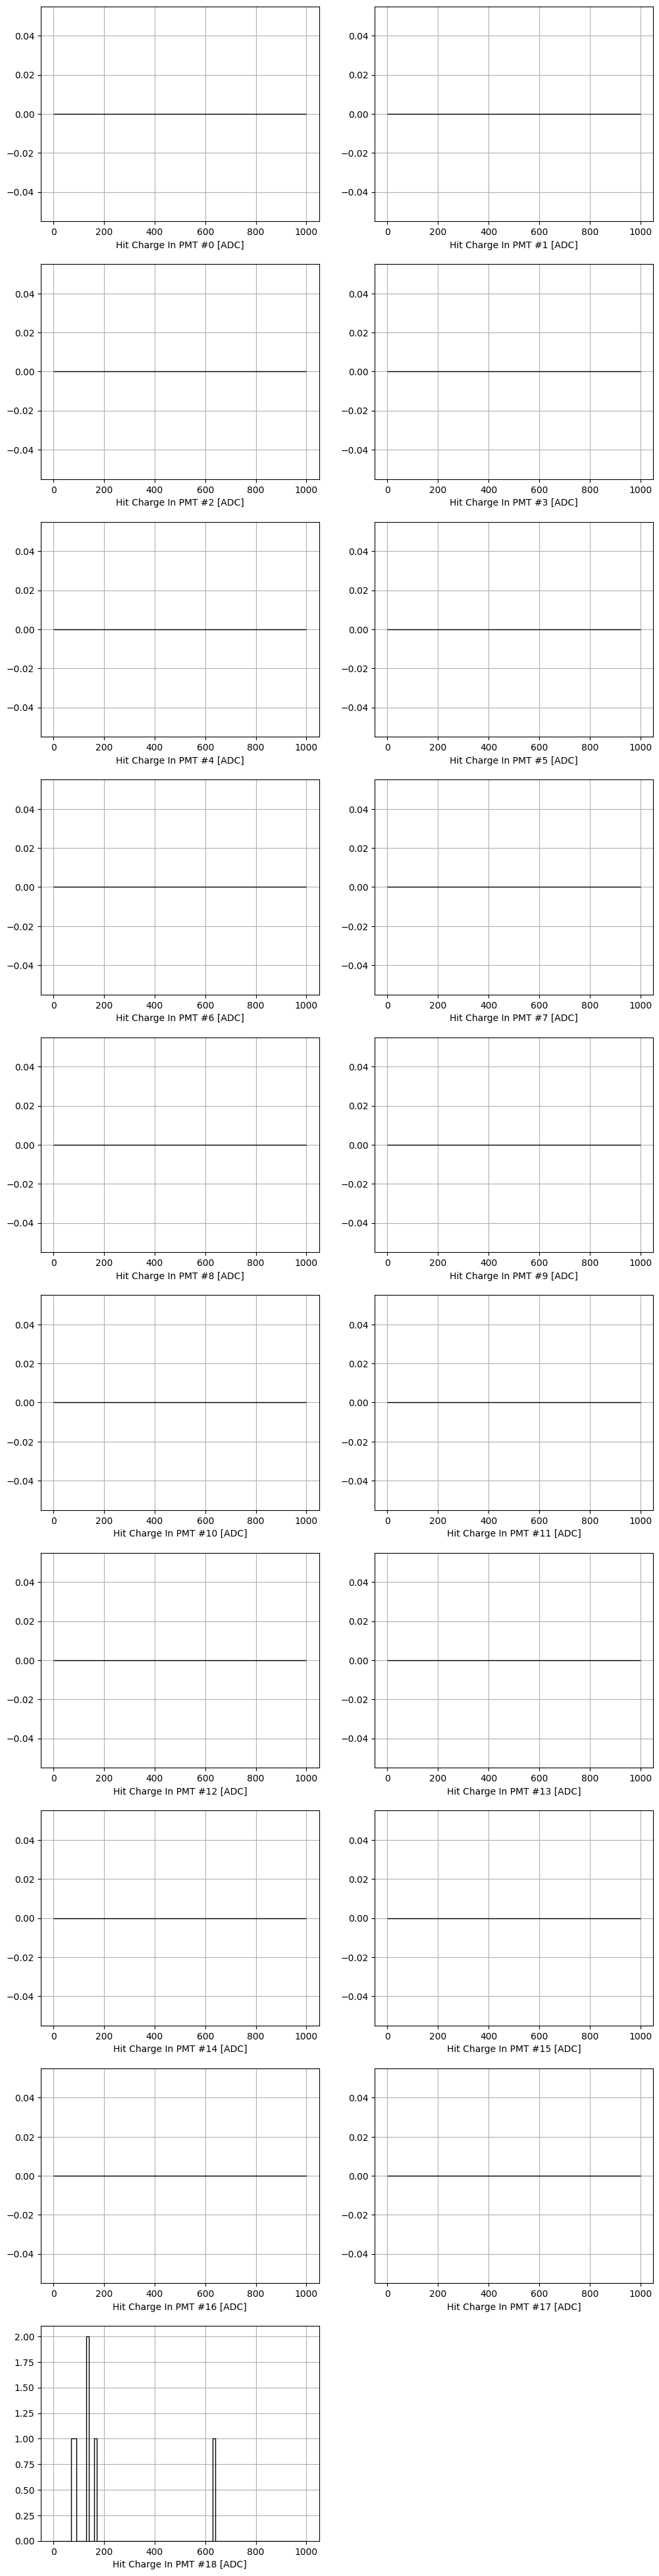

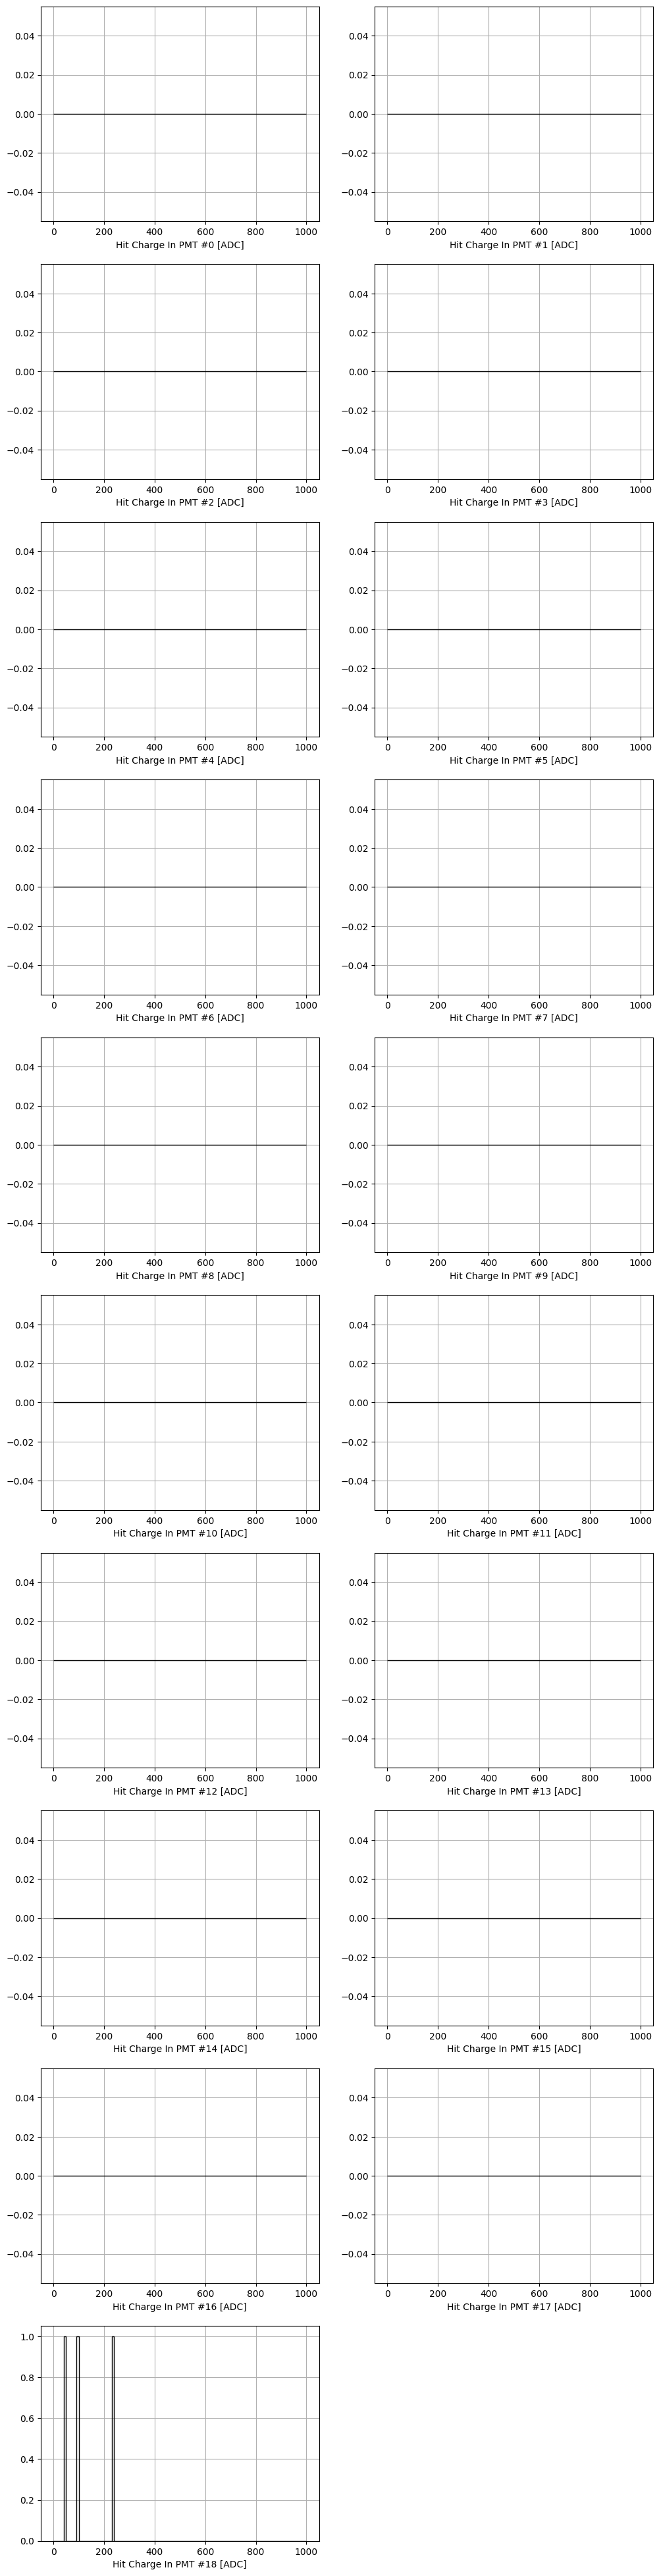

In [ ]:
plt.style.use('default');
pltext.style()

plotCharges(df_sig)
plotCharges(df_bkg)
plotCharges(df_sig_pre)
plotCharges(df_sig_pos)
plotCharges(df_bkg_pre)
plotCharges(df_bkg_pos)

In [ ]:
subplot = pltext.canvas(19)
mean_charge = []
mean_charge_err = []
for pmt in tqdm(range(2014), total=2014):
    charge = df_sig[df_sig["pmt_id"].values == pmt]["hit_pmt_charges"].values
    # subplot(pmt+1)
    # pltext.hist(charge, 100, range=(0, 1e3), stats=False, xylabels=f"Hit Charge In PMT #{pmt} [ADC]");
    try:
        h = pltext.hfit(charge, 100, "gaus", range=(0, 400));
    except:
        mean_charge.append(0)
        mean_charge_err.append(0)
        continue
    plt.close()
    mean_charge.append(h[3][1])
    mean_charge_err.append(h[4][1])

100%|██████████| 2014/2014 [00:36<00:00, 55.70it/s] 


In [ ]:
np.mean(mean_charge), np.sqrt(np.sum(np.array(mean_charge_err)**2))/len(mean_charge_err)

(np.float64(115.36328026045189), np.float64(0.11203244369750992))

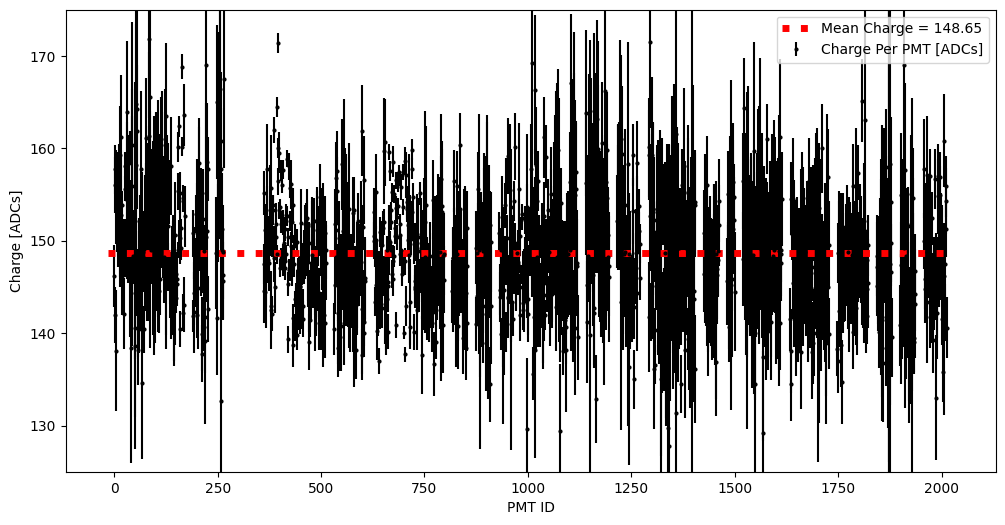

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.errorbar(range(2014), mean_charge, yerr=mean_charge_err, fmt='o', markersize=2, label="Charge Per PMT [ADCs]");
plt.ylim(125, 175);
plt.hlines(np.mean([i for i in mean_charge if i!=0]), -15, 2029, linestyles=":", color="red", linewidth=5,label=f"Mean Charge = {np.mean([i for i in mean_charge if i!=0]):.2f}");
plt.xlabel("PMT ID");
plt.ylabel("Charge [ADCs]");
plt.legend();

# Hits Per PMT For Each Sample Of Signal

In [62]:
all_pmts = np.arange(2014)   # por ejemplo 0..N_PMTS-1
hits_per_pmt_sig     = (df_sig.groupby("pmt_id")["candidate_id"].count().reindex(all_pmts, fill_value=0)    )
hits_per_pmt_sig_pre = (df_sig_pre.groupby("pmt_id")["candidate_id"].count().reindex(all_pmts, fill_value=0))*noCandidateSig/len(df_sig_pre["candidate_id"].unique())
hits_per_pmt_sig_pos = (df_sig_pos.groupby("pmt_id")["candidate_id"].count().reindex(all_pmts, fill_value=0))*noCandidateSig/len(df_sig_pos["candidate_id"].unique())
hits_per_pmt_bkg     = (df_bkg.groupby("pmt_id")["candidate_id"].count().reindex(all_pmts, fill_value=0)    )*noCandidateSig/noCandidateBkg
hits_per_pmt_bkg_pre = (df_bkg_pre.groupby("pmt_id")["candidate_id"].count().reindex(all_pmts, fill_value=0))*noCandidateSig/len(df_bkg_pre["candidate_id"].unique())
hits_per_pmt_bkg_pos = (df_bkg_pos.groupby("pmt_id")["candidate_id"].count().reindex(all_pmts, fill_value=0))*noCandidateSig/len(df_bkg_pos["candidate_id"].unique())

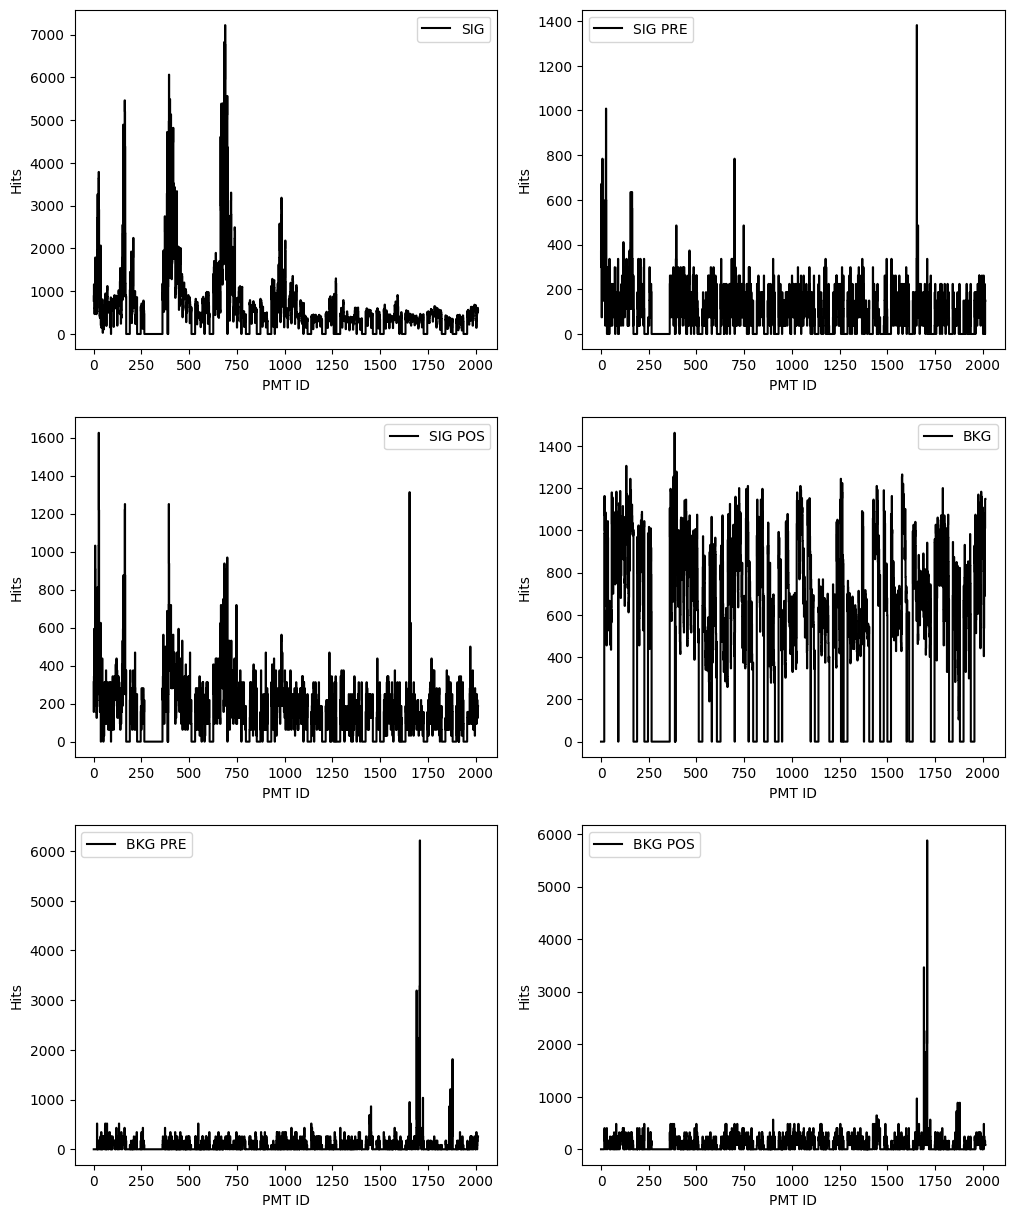

In [63]:
subplot = pltext.canvas(6)

# SIGNAL HITS
subplot(1)
plt.step(range(2014), hits_per_pmt_sig, label="SIG");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.legend();

# PRETRIGGER WINDOW SIG HITS
subplot(2)
plt.step(range(2014), hits_per_pmt_sig_pre, label="SIG PRE");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.legend();

# POSTRIGGER WINDOW SIG HITS
subplot(3)
plt.step(range(2014), hits_per_pmt_sig_pos, label="SIG POS");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.legend();

# BACKGROUND HITS
subplot(4)
plt.step(range(2014), hits_per_pmt_bkg, label="BKG");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.legend();

# PRETRIGGER WINDOW BKG HITS
subplot(5)
plt.step(range(2014), hits_per_pmt_bkg_pre, label="BKG PRE");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.legend();

# PRETRIGGER WINDOW BKG HITS
subplot(6)
plt.step(range(2014), hits_per_pmt_bkg_pos, label="BKG POS");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.legend();

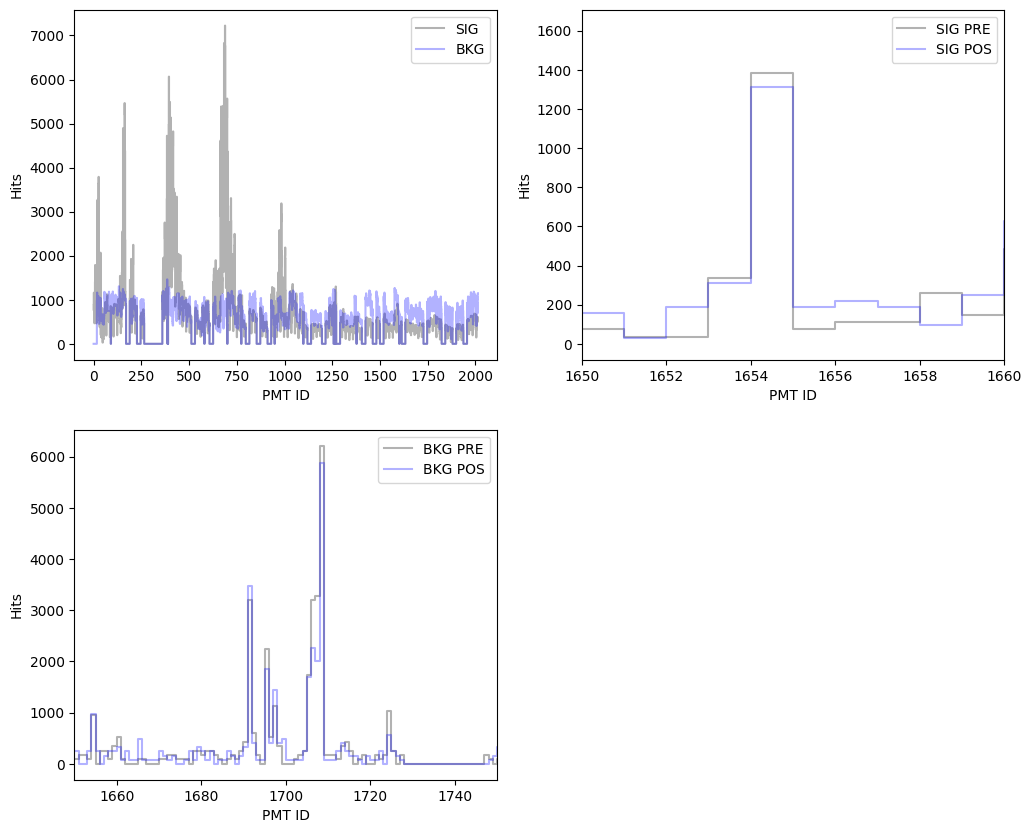

In [65]:
subplot = pltext.canvas(3)

subplot(1)
plt.step(range(2014), hits_per_pmt_sig, alpha=0.3, label="SIG");
plt.step(range(2014), hits_per_pmt_bkg, alpha=0.3, label="BKG");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.legend();

subplot(2)
plt.step(range(2014), hits_per_pmt_sig_pre, alpha=0.3, label="SIG PRE");
plt.step(range(2014), hits_per_pmt_sig_pos, alpha=0.3, label="SIG POS");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.xlim(1650, 1660);
plt.legend();

subplot(3)
plt.step(range(2014), hits_per_pmt_bkg_pre, alpha=0.3, label="BKG PRE");
plt.step(range(2014), hits_per_pmt_bkg_pos, alpha=0.3, label="BKG POS");
plt.xlabel("PMT ID");
plt.ylabel("Hits");
plt.xlim(1650, 1750);
# plt.yscale("log");
plt.legend();

Sigma BKG = 11.783092414977837
Sigma SIG = 13.012700525036168


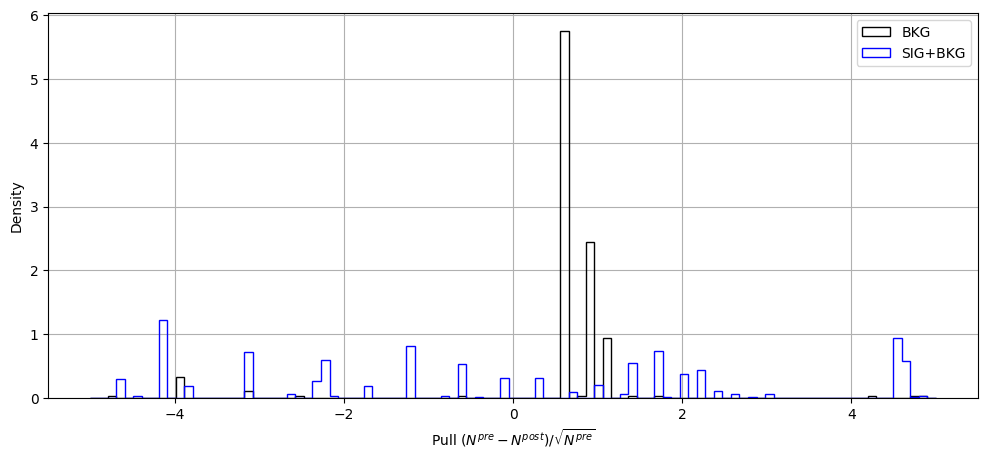

In [ ]:
# Arrays numpy
pre_bkg  = hits_per_pmt_bkg_pre.values
post_bkg = hits_per_pmt_bkg_pos.values

# máscara para evitar división por cero
mask_bkg = pre_bkg > 0

pull_bkg = (pre_bkg[mask_bkg] - post_bkg[mask_bkg]) / np.sqrt(pre_bkg[mask_bkg])

pre_sig  = hits_per_pmt_sig_pre.values
post_sig = hits_per_pmt_sig_pos.values

mask_sig = pre_sig > 0

pull_sig = (pre_sig[mask_sig] - post_sig[mask_sig]) / np.sqrt(pre_sig[mask_sig])

subplot = pltext.canvas(1)

bins_pull = np.linspace(-5, 5, 100)

plt.hist(pull_bkg, bins=bins_pull, histtype="step", density=True, label="BKG")
plt.hist(pull_sig, bins=bins_pull, histtype="step", density=True, label="SIG+BKG")

plt.xlabel("Pull $(N^{pre}-N^{post})/\sqrt{N^{pre}}$")
plt.ylabel("Density")
plt.grid(True)
plt.legend()

print("Sigma BKG =", np.std(pull_bkg))
print("Sigma SIG =", np.std(pull_sig))